# Project 1a: Text Classification Using Logistic Regression
Author: Kabir Ahuja

Thanks to Riva Gore for feedback and Kavel Rao for designing the autograder.

In this project, you will implement linear text classifiers for sentiment analysis. We will be working with [Stanford Sentiment Tree (SST) Bank](https://nlp.stanford.edu/sentiment/) which contains movie reviews with sentiment labels. We will consider both the binary version (only two labels positive and negative) as well as 5 label version (very negative, negative, neutral, positive, very positive). In particular you will learn:

- How to convert text inputs to features
- How to train logistic regression models from scratch
- How to evaluate classification models
- Interpreting trained linear models

In [71]:
# Install required libraries
!pip install numpy
!pip install pandas
!pip install nltk
!pip install torch
!pip install tqdm
!pip install matplotlib
!pip install seaborn


[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 23.2.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


In [72]:
# We start by importing libraries that we will be making use of in the assignment.
import os
import string
from typing import List, Dict
from typing import Tuple

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import tqdm

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/rbmuk/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/rbmuk/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [73]:
# !wget https://homes.cs.washington.edu/~kahuja/cse447/project1/data.zip -O data.zip
# !unzip -o data.zip

# Set data directory. Important: DO NOT CHANGE THIS. AUTOGRADER WILL FAIL ON YOUR SUBMISSION OTHERWISE
parent_dir = os.path.dirname(os.path.abspath("__file__"))
data_dir = os.path.join(parent_dir, "data")

We will start by loading the datasets that we will be working with today

In [74]:
train_df = pd.read_csv(f"{data_dir}/sst_train_binary.csv")
dev_df = pd.read_csv(f"{data_dir}/sst_dev_binary.csv")

train_df_multiclass = pd.read_csv(f"{data_dir}/sst_train_multiclass.csv")
dev_df_multiclass = pd.read_csv(f"{data_dir}/sst_dev_multiclass.csv")

In [75]:
train_df.head()

,sentence,label
0,The Rock is destined to be the 21st Century 's...,1
1,The gorgeously elaborate continuation of `` Th...,1
2,Singer\/composer Bryan Adams contributes a sle...,1
3,You 'd think by now America would have had eno...,0
4,Yet the act is still charming here .,1


In [76]:
train_df_multiclass.head()

,sentence,label
0,The Rock is destined to be the 21st Century 's...,3
1,The gorgeously elaborate continuation of `` Th...,4
2,Singer\/composer Bryan Adams contributes a sle...,3
3,You 'd think by now America would have had eno...,2
4,Yet the act is still charming here .,3


We only release the sentences for the test dataset, which you will use to submit your predictions.

In [77]:
test_df = pd.read_csv(f"{data_dir}/sst_test_release.csv")
test_df.head()

,sentence,label
0,Effective but too-tepid biopic,-1
1,If you sometimes like to go to the movies to h...,-1
2,"Emerges as something rare , an issue movie tha...",-1
3,The film provides some great insight into the ...,-1
4,Offers that rare combination of entertainment ...,-1


## Part 1: Converting Text To Features

Typical ML models work on the data described using mathematical objects like vectors and matrices, which are often referred to as features. These features can be of different types depending upon the downstream application, like for building a classifier to predict whether to give credit to a customer we might consider features like their age, income, employement status etc. In the same way to build a classifier for textual data, we need a way to describe each text example in terms of numeric features which can then be fed to the classification algorithm of our choice.

### Exercise 1.1 Linguistic Features (2 Points)

Pre-deep learning era it was common to represent text data using features defined using linguistic insights for solving different tasks. E.g. Jurafsky and Martin define the following 6 features for sentiment analysis:

![image.png](https://homes.cs.washington.edu/~kahuja/cse447/project1/linguistic_features.png)

Implement the class `LinguisticVectorizer` which extracts these features from the text documents. We have provided the positive lexicon and negative lexicon word lists in the constructor for you to use.

In [78]:
class LinguisticVectorizer:

    def __init__(self):

        with open(f"{data_dir}/lexicon/positive-words.txt", "r") as f:
            self.positive_words = set(f.read().splitlines())
        with open(f"{data_dir}/lexicon/negative-words.txt", "r") as f:
            self.negative_words = set(f.read().splitlines())

        self.first_person_pronouns = {"i", "me", "my", "mine", "we", "us", "our", "ours"}
        self.second_person_pronouns = {"you", "your", "yours"}

    def transform(self, documents: List[str]) -> torch.FloatTensor:

        """
        Extract the x_1, x_2, ..., x_6 features from Jurafsky and Martin for each text document.

        Inputs:
        - documents: a list of strings, where each string represents the text of a document.

        Returns:
        - features: a torch.FloatTensor of shape (N, 6) where N is the number of documents.

        Note: lexicon lists have all words in lowercase.
        """

        features = torch.zeros(len(documents), 6)

        # YOUR CODE HERE
        for i, document in enumerate(documents):
            words = document.lower().split()
            x1 = sum([1 for word in words if word in self.positive_words])

            x2 = sum([1 for word in words if word in self.negative_words])

            x3 = words.count('no') > 0
            x4 = sum([1 for word in words if word in self.first_person_pronouns or word in self.second_person_pronouns])

            x5 = words.count("!") > 0

            x6 = torch.log(torch.tensor(len(words)))

            features[i] = torch.tensor([x1, x2, x3, x4, x5, x6])

        return features

In [79]:
# Sample test cases


def evaluate_test_case(
    input, output, expected_output, output_str="Output", atol=1e-4
) -> Dict:

    if input is not None:
        print("Input:\n", input)
    print(f"{output_str}:\n", output)
    print(f"Expected {output_str}:\n", expected_output)

    match = (
        output == expected_output
        if type(output) == str
        else np.allclose(output, expected_output, atol=atol)
    )

    if match:
        print("Test case passed! :)")

    else:
        print("Test case failed! :(")

    print("\n" + "=" * 50 + "\n")


def evaluate_list_test_cases(
    test_case_input, test_case_func_output, test_case_exp_output
):

    print(f"Input: {test_case_input}")
    print(f"Function Output: {test_case_func_output}")
    print(f"Expected Output: {test_case_exp_output}")

    if test_case_func_output == test_case_exp_output:
        print("Test Case Passed :)")
        print("**********************************\n")
        return True
    else:
        print("Test Case Failed :(")
        print("**********************************\n")
        return False


def evaluate_tensor_test_cases(
    test_case_input, test_case_func_output, test_case_exp_output
):

    print(f"Input: {test_case_input}")
    print(f"Function Output: {test_case_func_output}")
    print(f"Expected Output: {test_case_exp_output}")

    if torch.allclose(test_case_func_output, test_case_exp_output, atol=1e-4):
        print("Test Case Passed :)")
        print("**********************************\n")
        return True
    else:
        print("Test Case Failed :(")
        print("**********************************\n")
        return False

print("Sample Test Case 1")
linguistic_vectorizer = LinguisticVectorizer()
documents = [
    "It's hokey . There are virtually no surprises , and the writing is second-rate . So why was it so enjoyable ? For one thing , the cast is great . Another nice touch is the music . I was overcome with the urge to get off the couch and start dancing . It sucked me in , and it'll do the same to you ."
]
features = linguistic_vectorizer.transform(documents)
expected_features = torch.FloatTensor([
    3, 2, 1, 3, 0, torch.log(torch.tensor(66.0))
])

evaluate_tensor_test_cases(
    documents, features, expected_features
)

print("Sample Test Case 2")
linguistic_vectorizer = LinguisticVectorizer()
documents = [
    "I loved this movie . It was great . The music was awesome . I would watch it again .",
    "The movie was terrible . The acting was bad . I would not recommend it to anyone ."
]
features = linguistic_vectorizer.transform(documents)
expected_features = torch.FloatTensor([
    [3, 0, 0, 2, 0, torch.log(torch.tensor(20))],
    [1, 2, 0, 1, 0, torch.log(torch.tensor(18))]
])
evaluate_tensor_test_cases(
    documents, features, expected_features
)

Sample Test Case 1
Input: ["It's hokey . There are virtually no surprises , and the writing is second-rate . So why was it so enjoyable ? For one thing , the cast is great . Another nice touch is the music . I was overcome with the urge to get off the couch and start dancing . It sucked me in , and it'll do the same to you ."]
Function Output: tensor([[3.0000, 2.0000, 1.0000, 3.0000, 0.0000, 4.1897]])
Expected Output: tensor([3.0000, 2.0000, 1.0000, 3.0000, 0.0000, 4.1897])
Test Case Passed :)
**********************************

Sample Test Case 2
Input: ['I loved this movie . It was great . The music was awesome . I would watch it again .', 'The movie was terrible . The acting was bad . I would not recommend it to anyone .']
Function Output: tensor([[3.0000, 0.0000, 0.0000, 2.0000, 0.0000, 2.9957],
        [1.0000, 2.0000, 0.0000, 1.0000, 0.0000, 2.8904]])
Expected Output: tensor([[3.0000, 0.0000, 0.0000, 2.0000, 0.0000, 2.9957],
        [1.0000, 2.0000, 0.0000, 1.0000, 0.0000, 2.8904

True

Let's get the features for our training and dev set

In [80]:
linguistic_vectorizer = LinguisticVectorizer()
train_features = linguistic_vectorizer.transform(train_df["sentence"])
dev_features = linguistic_vectorizer.transform(dev_df["sentence"])

### Exercise 1.2 Bag of Words Features (6 Points)

While the linguistic features that we defined above might be effective for some cases, it is also very easy to find cases where they will miss on modeling some important aspect of the original text. E.g. the features we defined above do not handle negation. Hence, in the example "I would not recommend it", "recommend" gets counted as a positive lexicon. While we can define features to handle such cases, it can get very tedius trying to capture all such cases.

Bag of Words model is another method to encode documents into features and requires little manual interventions to define features In bag of words, we represent a document as an unordered collection of words in that document. One way this is commonly done is by counting occurence (or frequency) of each word in a given document and using it as a feature for training the classifier. The order in which these words occur in the text is not relevant and we are just concerned with which words are present in the text. Consider the following example to understand how bag of words are used to represent text.

As an example consider we have 2 examples present in our dataset:

x1: john likes to watch movies mary likes movies too

x2: mary also likes to watch football games

Based on these two documents we can get the list of all words that occur in this dataset which will be:

| index | word     |
|-------|----------|
| 0     | also     |
| 1     | football |
| 2     | games    |
| 3     | john     |
| 4     | likes    |
| 5     | mary     |
| 6     | movies   |
| 7     | to       |
| 8     | too      |
| 9     | watch    |

We can then define features for the two x1 and x2 as follows:


|    | also | football | games | john | likes | mary | movies | to | too | watch |
|----|------|----------|-------|------|-------|------|--------|----|-----|-------|
| x1 | 0    | 0        | 0     | 1    | 2     | 1    | 2      | 1  | 1   | 1     |
| x2 | 1    | 1        | 1     | 0    | 1     | 1    | 0      | 1  | 0   | 1     |

These features can then be used to train an ML model. To summarize the following two steps must be followed to create bag of word representations of the text examples in a dataset.

- Step 1: Create a word vocabulary by iterating through all the documents in the **training** dataset, storing all the unique words that are present in each document. Also maintain mappings to map each word to an index and vice-versa, which we will need to define values for each feature dimension.

- Step 2: For each document in the training and test sets, get the frequency of each word in our vocabulary and use it to define feature for that example.


Below you will implement the class `BOWVectorizer`, which provides the functionality to convert text documents into features by executing the two steps we described above. Specifically, you will be implementing the `fit` function that creates vocabulary and word-to-index mappings from training data and a `transform` function which converts a text into BOW features

In [81]:
class BOWVectorizer:

    def fit(self, train_data: List[str]):

        """
        Given a list of documents in training data creates a word vocabulary and containing all words that occur in the training data.

        Inputs:
        - train_data: List of strings where each string represents a document

        Note: Make sure to sort the words in your vocabulary in lexicographical order.
        """

        self.vocab = set()
        self.word2idx = None

        # YOUR CODE HERE
        for document in train_data:
            words = document.split()
            self.vocab.update(words)

        self.vocab = sorted(list(self.vocab))
        self.word2idx = {word: i for i, word in enumerate(self.vocab)}

    def transform(self, documents: List[str]) -> torch.FloatTensor:

        """
        Converts a list of documents into a matrix of token counts.

        Inputs:
        - documents: List of strings where each string represents a document

        Outputs:
        - Returns a torch.tensor of shape (N, V) where N is the number of documents and V is the size of the vocabulary
        """

        bow_features = torch.zeros(len(documents), len(self.vocab))

        # YOUR CODE HERE
        for i, document in enumerate(documents):
            words = document.split()
            for word in words:
                bow_features[i][self.word2idx[word]] += 1

        return bow_features

Sample Test cases

In [82]:
print("Running Sample Test cases for `fit` method")
print("Sample Test Case 1:")
documents = [
    "john likes to watch movies mary likes movies too",
    "mary also likes to watch football games",
]
bow_vectorizer = BOWVectorizer()
bow_vectorizer.fit(documents)
test_documents = [
    "john likes to watch movies mary likes movies too",
    "mary also likes to watch football games",
]
expected_answer = torch.tensor([[0, 0, 0, 1, 2, 1, 2, 1, 1, 1], [1, 1, 1, 0, 1, 1, 0, 1, 0, 1]]).float()
evaluate_tensor_test_cases(
    test_documents, bow_vectorizer.transform(test_documents), expected_answer
)


Running Sample Test cases for `fit` method
Sample Test Case 1:
Input: ['john likes to watch movies mary likes movies too', 'mary also likes to watch football games']
Function Output: tensor([[0., 0., 0., 1., 2., 1., 2., 1., 1., 1.],
        [1., 1., 1., 0., 1., 1., 0., 1., 0., 1.]])
Expected Output: tensor([[0., 0., 0., 1., 2., 1., 2., 1., 1., 1.],
        [1., 1., 1., 0., 1., 1., 0., 1., 0., 1.]])
Test Case Passed :)
**********************************



True

Let's create BOW Features for the SST Dataset

In [83]:
# Training the BOWVectorizer on the SST training data
bow_vectorizer  = BOWVectorizer()
bow_vectorizer.fit(train_df["sentence"].values)

# Selecting the first training example
train_example = train_df["sentence"].values[0]
features = bow_vectorizer.transform([train_example])
print(f"Shape of the feature vector : {features.shape}")
print(f"Number of training examples : {len(train_df)}")

Shape of the feature vector : torch.Size([1, 18172])
Number of training examples : 8544


As you can see we have around 18k features for each example! This is specially concerning because our training dataset size is less than half of the number of features. This can very easily lead the model to overfit on training data. Recall that each feature corresponds to a word in the vocabulary. One way we can reduce the features is by normalizing words in the vocabulary. E.g. currently we have been treating lowercase and uppercase versions of a word as different words. We can apply *case folding* i.e. lowercasing all the words in our dataset. Another trick that can significantly reduce the number of features is to get rid of words which occur very rarely in the training data and replace them with an \<unk\> token. Similarly we can remove punctuations from the text. We can also get rid of the so called *stop-words*. These are the words which are very commonly used in a language but often do not carry significant meaning, e.g. "the", "he", "for" etc. NLTK package provides us a list of stop words which can be accessed by:

```
from nltk.corpus import stopwords
STOPWORDS = stopwords.words("english")
```

Implement `BOWVectorizerWNomalizer` class below, which first applies the four text processing techniques mentioned above, to the documents both before we use them to train the features or before transforming them.

In [84]:
class BOWVectorizerWNormalizer(BOWVectorizer):

    def __init__(self, lower_case=True, replace_rare_words_wth_unks = True, remove_punctuation=True, remove_stopwords=True, min_word_freq=3):

        self.lower_case = lower_case
        self.replace_rare_words_wth_unks = replace_rare_words_wth_unks
        self.remove_punctuation = remove_punctuation
        self.remove_stopwords = remove_stopwords
        self.min_word_freq = min_word_freq

        self.stop_words = set(nltk.corpus.stopwords.words("english"))
        self.punctuation = set(string.punctuation)
        
        self.vocab: List[str] = []
        self.word2idx = None

    def fit(
        self,
        train_data: List[str]
    ):
        """
        Given a list of documents in training data creates a word vocabulary containing all words **post normalization** that occur in the training data.

        Inputs:
        - train_data: List of strings where each string represents a document

        """
        word_freq = nltk.FreqDist(word for doc in train_data for word in doc.split())

        for doc in train_data:
          for word in self.normalize(doc).split():
            if not self.replace_rare_words_wth_unks or word_freq.get(word, 0) >= self.min_word_freq:
              self.vocab.append(word)
            elif self.replace_rare_words_wth_unks:
              self.vocab.append('<unk>')

        # sort
        self.vocab = sorted(set(self.vocab))

        self.word2idx = dict(zip(self.vocab, range(len(self.vocab))))


    def transform(self, documents: List[str]) -> torch.FloatTensor:
        """
        Transforms a list of documents into a matrix of token counts.

        Inputs:
        - documents: List of strings where each string represents a document

        Outputs:
        - Returns a torch.tensor of shape (N, V) where N is the number of documents and V is the size of the vocabulary
        """

        bow_features = torch.zeros(len(documents), len(self.vocab))

        # YOUR CODE HERE
        for i, document in enumerate(documents):
            document = self.normalize(document)
            words = document.split()

            for word in words:
                if word in self.vocab:
                  bow_features[i][self.word2idx[word]] += 1
                elif '<unk>' in self.vocab:
                  bow_features[i][self.word2idx['<unk>']] += 1
        return bow_features

    # Helper functions to normalize the document
    # YOUR CODE HERE
    def normalize(self, document: str) -> List[str]:
        if self.lower_case:
            document = document.lower()
        if self.remove_punctuation:
            for punctuation in self.punctuation:
                document = document.replace(punctuation, '')
        if self.remove_stopwords:
            document = ' '.join([word for word in document.split() if word not in self.stop_words])
        return document

In [120]:
print("Normalization by applying only lower casing")
bow_vectorizer = BOWVectorizerWNormalizer(
    lower_case=True, replace_rare_words_wth_unks = False, remove_punctuation=False, remove_stopwords=False
)
bow_vectorizer.fit(train_df["sentence"].values)
train_example = train_df["sentence"].values[0]
features = bow_vectorizer.transform([train_example])
print(f"Shape of the feature vector : {features.shape}")

print("Normalization by also replacing rare words with <unk>")
bow_vectorizer = BOWVectorizerWNormalizer(
    lower_case=True, replace_rare_words_wth_unks = True,  remove_punctuation=False, remove_stopwords=False
)
bow_vectorizer.fit(train_df["sentence"].values)
train_example = train_df["sentence"].values[0]
features = bow_vectorizer.transform([train_example])
print(f"Shape of the feature vector : {features.shape}")

print("Normalization by also removing punctuation")
bow_vectorizer = BOWVectorizerWNormalizer(
    lower_case=True,
    replace_rare_words_wth_unks=True,
    remove_punctuation=True,
    remove_stopwords=False,
)
bow_vectorizer.fit(train_df["sentence"].values)
train_example = train_df["sentence"].values[0]
features = bow_vectorizer.transform([train_example])
print(f"Shape of the feature vector : {features.shape}")

print("Normalization by also removing stopwords")
bow_vectorizer = BOWVectorizerWNormalizer(
    lower_case=True,
    replace_rare_words_wth_unks=True,
    remove_punctuation=True,
    remove_stopwords=True,
)
bow_vectorizer.fit(train_df["sentence"].values)
features = bow_vectorizer.transform([train_example])
print(f"Shape of the feature vector : {features.shape}")

Normalization by applying only lower casing
Shape of the feature vector : torch.Size([1, 16473])
Normalization by also replacing rare words with <unk>
Shape of the feature vector : torch.Size([1, 4548])
Normalization by also removing punctuation
Shape of the feature vector : torch.Size([1, 4408])
Normalization by also removing stopwords
Shape of the feature vector : torch.Size([1, 4289])


You should see 16473 features with just lowercasing, 4548 with lowercasing and replacing rare words with \<unk\>, 4408 features on also removing punctuations, and 4289 features on applying all the four normalization techniques. As you can see we were able to reduce roughly 4 times the original number of features, and we have now way less features than the number of training examples. We can apply even more aggressive techniques like Lemmatization and Stemming to go even further, but these techniques can be tricky to work with  (see Chapter 2, section 2.6 of Jurafsky and Martin for details) and often not lead to much improved performance.

Let's get features for our training and dev sets now

In [121]:
bow_vectorizer = BOWVectorizerWNormalizer(
    lower_case=True, replace_rare_words_wth_unks=True,  remove_punctuation=True, remove_stopwords=True
)
bow_vectorizer.fit(train_df["sentence"].values)
train_bow_features = bow_vectorizer.transform(train_df["sentence"].values)
dev_bow_features = bow_vectorizer.transform(dev_df["sentence"].values)

print(f"Shape of the training feature matrix : {train_bow_features.shape}")
print(f"Shape of the dev feature matrix : {dev_bow_features.shape}")

Shape of the training feature matrix : torch.Size([8544, 4289])
Shape of the dev feature matrix : torch.Size([1101, 4289])


## Part 2: Binary Logistic Regression

We will now start building our first text classifier! We will start with Logistic Regression for binary classification i.e. where each input can be classified into one of the two labels. Consider an input $\pmb{x} \in \mathbb{R}^d$ defining the feature vector and label $y \in \{0,1\}$. Recall from the lectures that logistic regression has the following functional form:

$$ \hat{y} = P(y = 1) = \sigma(\pmb{w}^T\pmb{x} + b)$$

where, $\sigma$ is the sigmoid function:

$$\sigma(x) = \frac{1}{1 + \exp(-x)}$$

and the weight vector $\pmb{w} \in \mathbb{R}^d$ and the bias term $b \in \mathbb{R}$ are the learnable parameters in the model.

In [87]:
# Getting labels for the training and dev data binary classification
y_train = torch.tensor(train_df["label"].values).unsqueeze(1)
y_dev = torch.tensor(dev_df["label"].values).unsqueeze(1)
print(f"Shape of the training labels : {y_train.shape}")
print(f"Shape of the dev labels : {y_dev.shape}")

Shape of the training labels : torch.Size([8544, 1])
Shape of the dev labels : torch.Size([1101, 1])


Text(0.5, 1.0, 'Dev Data Label Distribution')

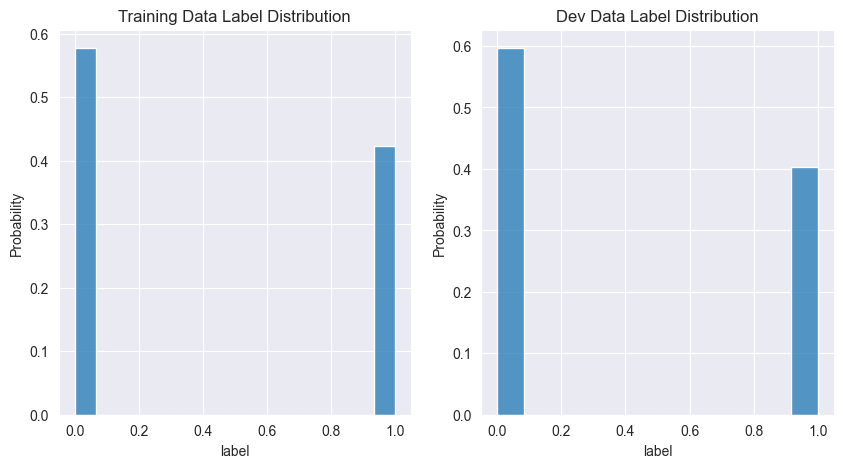

In [88]:
# Check label distribution

fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(train_df["label"], stat="probability")
plt.title("Training Data Label Distribution")

plt.subplot(1, 2, 2)
sns.histplot(dev_df["label"], stat="probability")
plt.title("Dev Data Label Distribution")

### Exercise 2.1: Logistic Regression Prediction (2 Points)
We shall soon see how we can learn the parameters $w$ and $b$ from training data. For now implement `LogisticRegression` class below, that initializes the parameters (to zeros) and provides a method to get output from a logistic regression model.

In [89]:
class LogisticRegression:

    def __init__(self, d: int) -> None:
        """
        Initialize the weights and bias to zeros for the logistic regression model.

        Inputs:
        - d: An integer representing the number of features
        """

        self.weights = torch.zeros(d, 1)
        self.bias = torch.tensor(0.)

        # YOUR CODE HERE


    def sigmoid(self, z: torch.FloatTensor) -> torch.FloatTensor:
        """
        Compute the sigmoid of z

        Inputs:
        - z : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples

        Returns:
        - A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples
        """

        # YOUR CODE HERE
        return 1/(1 + torch.exp(-z))

    def forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        """
        Compute the forward pass of the logistic regression model.

        Inputs:
        - x : A torch.FloatTensor of shape (N, d) where N is the number of samples and d number of features

        Returns:
        - A torch.FloatTensor of shape (N, 1) where N is the number of samples
        """

        # YOUR CODE HERE
        return self.sigmoid(x @ self.weights + self.bias)

    def __call__(self, x: torch.FloatTensor) -> torch.FloatTensor:
        """
        Make a forward pass call to the logistic regression model.
        Only exists so that we can directly call the object to make predictions instead of calling the forward method.

        Inputs:
        - x : A torch.FloatTensor of shape (N, d) where N is the number of samples and d number of features

        Returns:
        - A torch.FloatTensor of shape (N, 1) where N is the number of samples
        """

        return self.forward(x)


In [90]:
# Sample Test Cases
print("Running Sample Test Case 1")
d = 6
logistic_regression = LogisticRegression(d)
print("Initialized weights: {}".format(logistic_regression.weights))
print("Initialized bias: {}".format(logistic_regression.bias))
x = torch.tensor([[1, 2, 3, 4, 5, 6]], dtype=torch.float)
output = logistic_regression(x)
expected_output = torch.tensor([[0.5]])
evaluate_tensor_test_cases(x, output, expected_output)

print("Running Sample Test Case 2")
d = 4
logistic_regression = LogisticRegression(d)
torch.manual_seed(42)
# Modifying weights and bias
logistic_regression.weights = torch.randn(d, 1)
logistic_regression.bias = torch.randn(1)
print("Modified weights: {}".format(logistic_regression.weights))
print("Modified bias: {}".format(logistic_regression.bias))
x = torch.tensor([[1, 2, 3, 4]], dtype=torch.float)
output = logistic_regression(x)
expected_output = torch.tensor([[0.7495]])
evaluate_tensor_test_cases(x, output, expected_output)

print("Running Sample Test Case 3")
d = len(train_bow_features[0])
logistic_regression = LogisticRegression(d)
torch.manual_seed(42)
# Modifying weights and bias
logistic_regression.weights = torch.randn(d, 1)
logistic_regression.bias = torch.randn(1)
print("Modified weights: {}".format(logistic_regression.weights))
print("Modified bias: {}".format(logistic_regression.bias))
output = logistic_regression(train_bow_features[:10])
expected_output = torch.tensor(
    [
        [5.5713e-08],
        [1.1644e-07],
        [3.5172e-09],
        [3.5451e-05],
        [1.5206e-02],
        [3.0002e-09],
        [3.8574e-01],
        [2.3933e-04],
        [3.0084e-03],
        [8.7595e-03],
    ]
)
evaluate_tensor_test_cases(train_bow_features[:10], output, expected_output)

print("Running Sample Test Case 4")
logistic_regression = LogisticRegression(2)
# Modifying weights and bias
logistic_regression.weights = torch.tensor([0.3, 0.3], dtype=torch.float).unsqueeze(1)
logistic_regression.bias = torch.tensor(2)
print("Modified weights: {}".format(logistic_regression.weights))
print("Modified bias: {}".format(logistic_regression.bias))
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float)
output = logistic_regression(x)
expected_output = torch.tensor([
    [0.947846],
    [0.9836975],
 ])
evaluate_tensor_test_cases(x, output, expected_output)

Running Sample Test Case 1
Initialized weights: tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])
Initialized bias: 0.0
Input: tensor([[1., 2., 3., 4., 5., 6.]])
Function Output: tensor([[0.5000]])
Expected Output: tensor([[0.5000]])
Test Case Passed :)
**********************************

Running Sample Test Case 2
Modified weights: tensor([[0.3367],
        [0.1288],
        [0.2345],
        [0.2303]])
Modified bias: tensor([-1.1229])
Input: tensor([[1., 2., 3., 4.]])
Function Output: tensor([[0.7495]])
Expected Output: tensor([[0.7495]])
Test Case Passed :)
**********************************

Running Sample Test Case 3
Modified weights: tensor([[ 1.9269],
        [ 1.4873],
        [ 0.9007],
        ...,
        [ 0.1439],
        [-0.1495],
        [ 1.1932]])
Modified bias: tensor([-0.4441])
Input: tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0.,

True

### Exercise 2.2 Binary Cross Entropy Loss (1 Point)

To train our model we need to first define a loss function that measures the error between the model's prediction of the label ($\hat{y}$) and the ground truth label ($y$). For logistic regression with binary labels, we use binary cross entropy (BCE) loss. For a given prediction, ground truth pair, the BCE loss is given as:

$$L_{\text{BCE}}(\hat{y}, y) = -[y \log \hat{y} + (1 - y) \log (1 - \hat{y})]$$

Plugging in the value of $\hat{y}$, we get:

$$ L_{\text{BCE}}(\pmb{w}, b \mid \pmb{x}, y) = -[y \log \sigma(\pmb{w}^T\pmb{x} + b) + (1 - y) \log (1 - \sigma(\pmb{w}^T\pmb{x} + b))]$$

To compute loss over the entire dataset $D$, we simply average the loss for all examples:

$$ L_{\text{BCE}}(\pmb{w}, b \mid D) = \frac{1}{m} \sum_{i = 1}^{m} L_{\text{BCE}}(\hat{y}_i, y_i)$$

where, $m$ is the number of examples in the dataset.

Implement the `bce_loss` function below, that takes in the predicted and ground truth labels and computes the average BCE loss.

In [91]:
def bce_loss(
    y_pred : torch.FloatTensor,
    y_true : torch.FloatTensor
) -> float:
    """
    Compute the binary cross entropy loss between y_pred and y_true.

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples
    - y_true : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples

    Returns:
    - A float representing the binary cross entropy loss
    """

    # YOUR CODE HERE
    return -torch.mean(y_true * torch.log(y_pred) + (1-y_true) * torch.log(1-y_pred))

In [92]:
# Sample Test Cases


print("Running Sample Test Case 1")
y_pred = torch.tensor([0.1])
y_true = torch.tensor([1.0])
output = bce_loss(y_pred, y_true)
expected_output = 2.3025851249694824
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if output == expected_output:
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

print("Running Sample Test Case 2")
y_pred = torch.tensor([[0.5]])
y_true = torch.tensor([[1.0]])
output = bce_loss(y_pred, y_true)
expected_output = 0.6931471824645996
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")


print("Running Sample Test Case 3")
y_pred = torch.tensor([0.9])
y_true = torch.tensor([1.0])
output = bce_loss(y_pred, y_true)
expected_output = 0.10536054521799088
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")

else:
    print("Test Case Failed :(")
print("**********************************\n")

print("Running Sample Test Case 4")
y_pred = torch.tensor([0.99])
y_true = torch.tensor([1.0])
output = bce_loss(y_pred, y_true)
expected_output = 0.010050326585769653
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")

else:
    print("Test Case Failed :(")
print("**********************************\n")


print("Running Sample Test Case 5")
y_pred = torch.tensor([0])
y_true = torch.tensor([1])
output = bce_loss(y_pred, y_true)
expected_output = torch.inf
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.eq(torch.tensor(output), torch.tensor(expected_output)):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

print("Running Sample Test Case 6")
y_pred = torch.tensor([1])
y_true = torch.tensor([1])
output = bce_loss(y_pred, y_true)
expected_output = torch.nan
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.isnan(torch.tensor(output)):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

print("Running Sample Test Case 7")
y_pred = torch.tensor([[0.1, 0.3, 0.5, 0.7, 0.9, 0.99]])
y_true = torch.tensor([[1.0, 1.0, 1.0, 1.0, 1.0, 1.0]])
output = bce_loss(y_pred, y_true)
expected_output = (
    torch.tensor(
        [
            2.3025851249694824,
            1.2039728164672852,
            0.6931471824645996,
            0.3566749691963196,
            0.10536054521799088,
            0.010050326585769653,
        ]
    )
    .mean()
    .item()
)
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")


print("Running Sample Test Case 8")
y_pred = torch.tensor([[0.1, 0.3, 0.5, 0.7, 0.9, 0.99]])
y_true = torch.tensor([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
output = bce_loss(y_pred, y_true)
expected_output = (
    torch.tensor(
        [
            0.10536054521799088,
            0.3566749691963196,
            0.6931471824645996,
            1.2039728164672852,
            2.3025848865509033,
            4.605171203613281,
        ]
    )
    .mean()
    .item()
)
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

Running Sample Test Case 1
y_pred: tensor([0.1000])
y_true: tensor([1.])
Output: 2.3025851249694824
Expected Output: 2.3025851249694824
Test Case Passed :)
**********************************

Running Sample Test Case 2
y_pred: tensor([[0.5000]])
y_true: tensor([[1.]])
Output: 0.6931471824645996
Expected Output: 0.6931471824645996
Test Case Passed :)
**********************************

Running Sample Test Case 3
y_pred: tensor([0.9000])
y_true: tensor([1.])
Output: 0.10536054521799088
Expected Output: 0.10536054521799088
Test Case Passed :)
**********************************

Running Sample Test Case 4
y_pred: tensor([0.9900])
y_true: tensor([1.])
Output: 0.010050326585769653
Expected Output: 0.010050326585769653
Test Case Passed :)
**********************************

Running Sample Test Case 5
y_pred: tensor([0])
y_true: tensor([1])
Output: inf
Expected Output: inf
Test Case Passed :)
**********************************

Running Sample Test Case 6
y_pred: tensor([1])
y_true: tensor([1])

/var/folders/b0/_vf1zhzn7zn9cqrkwzm_lm240000gn/T/ipykernel_60504/2928461584.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
/var/folders/b0/_vf1zhzn7zn9cqrkwzm_lm240000gn/T/ipykernel_60504/2928461584.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
/var/folders/b0/_vf1zhzn7zn9cqrkwzm_lm240000gn/T/ipykernel_60504/2928461584.py:60: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTe

### Exercise 2.3: Gradient Descent for Logistic Regression (4 Points)

We can now start training our sentiment classifier. One of the most commonly used optimization algorithms used in machine (and deep) learning is gradient descent. Recall from lectures that in gradient descent we iteratively update the weights of the model in the opposite direction of the gradient of loss function w.r.t. to the weights, i.e.,

$$ \theta^{t + 1} = \theta^t - \frac{\eta}{m} \nabla_{\theta} \sum_{i=1}^{m} L(f(x_i; \theta), y_i) $$

Note that for logistic regression, $L(f(x; \theta), y ) = L_{\text{BCE}}(\hat{y}, y)$. $\theta$ here denotes the parameters of the model, which for us is simply the weights $\pmb{w}$ and bias $b$. $\eta$ is also called learning rate, which determines the strength of every the update (too low then the convergence will be slow and too high we might overshoot the local minima).

The gradient of the BCE loss w.r.t $\pmb{w}$ is given by:


$$ \nabla_{w} L_{\text{BCE}}(\hat{y}_i, y_i) = [ \frac{\partial L_{\text{BCE}}(\hat{y}_i, y_i)}{\partial w_1}, \cdots,  \frac{\partial L_{\text{BCE}}(\hat{y}_i, y_i)}{\partial w_d}]^T $$

$$ \frac{\partial L_{\text{BCE}}(\hat{y}_i, y_i)}{\partial w_j} = - (y_i - \hat{y}_i)x_{ij} $$

Note that $x_{ij}$ refers to the $j^{th}$ feature of $i^{th}$ input.
Similarly, for the bias term we get:

$$ \nabla_{b} L_{\text{BCE}}(\hat{y}_i, y_i) = \frac{\partial L_{\text{BCE}}(\hat{y}_i, y_i)}{\partial b} = - (y_i - \hat{y}_i) $$

Plugging these into our gradient descent equation we get:

$$ w^{t+1}_j = w^{t}_j - \frac{\eta}{m} \sum_{i=1}^m (\hat{y}_i - y_i)x_{ij}$$

$$b^{t+1} = b^{t} - \frac{\eta}{m} \sum_{i=1}^m (\hat{y}_i - y_i)$$

Before we begin our implementation, there are two points to note. First you must have noticed that we sum over $m$ examples in our update equation. These are the all the examples in our training data. In practice, it can get very expensive to compute gradients w.r.t all examples, specially when we are dealing with huge datasets (millions or even billions of examples) and deep neural networks. In such cases, it is common to use stochastic or mini batch gradient descent, where for each update we only use a small batch of training data to update the weights (we use a different batch for every update till we exaust all the training data). An extreme case of this is where we only use one example at a time to update the weights:

$$ {w}^{t+1}_j = {w}^{t}_j - \eta (\hat{y}_i - y_i)x_{ij}$$

$$ {b}^{t+1} = {b}^{t} - \eta (\hat{y}_i - y_i)$$


Second, we wrote the above equations in terms of scalar variables and their summations. In practice, it can be much more efficient to vectorize these equations and use matrix operations which can make use of parallel computation. The vectorized version of our update rule will look like:


$$ \pmb{w}^{t+1} = \pmb{w}^t - \frac{\eta}{m} \pmb{X}^T(\pmb{\hat{y}} - \pmb{y})$$

$$ {b}^{t+1} = {b}^t - \frac{\eta}{m} \pmb{1}_d^T(\pmb{\hat{y}} - \pmb{y})$$

Here, $X \in \mathbb{R}^{m \times d}$ is the input matrix where each row is a feature vector for an input example. Similarly, $\pmb{y} \in \{0, 1\}^{m}$ is the vector containing labels for each example and $\pmb{\hat{y}} \in \mathbb{R}^{m}$ is the vector of predicted labels. $\pmb{1}_d \in {1}^d$ is a vector of all ones.

Below, you will implement `gradient_descent_update_vanilla` and `gradient_descent_update_vectorized`. The former using scalar operations and latter with vectorized update rule we described above.


In [93]:
def gradient_descent_update_vanilla(
    X: torch.FloatTensor,
    y: torch.FloatTensor,
    y_hat: torch.FloatTensor,
    w: torch.FloatTensor,
    b: torch.FloatTensor,
    learning_rate: float = 0.5,
):

    """
    Performs gradient descent update on w and b considering the binary cross entropy loss using scalar operations.

    Inputs:
    - X : A torch.FloatTensor of shape (m, d) where m is the number of samples and d number of features
    - y : A torch.FloatTensor containing ground truth labels of shape (m, 1) or (m,) where m is the number of samples
    - y_hat: A torch.FloatTensor containing predicted labels of shape (m, 1) or (m,) where m is the number of samples
    - w : A torch.FloatTensor of shape (d, 1) or (d,) where d is the number of features
    - b : A torch.FloatTensor of shape (1)
    - learning_rate : A float representing the learning rate

    Outputs:
    - torch.FloatTensor of shape (d, 1) or (d,) representing the updated weights
    - torch.FloatTensor of shape (1) representing the updated bias
    """

    w_updated = torch.zeros(X.shape[1], 1)
    b_updated = 0

    # YOUR CODE HERE
    for j in range(w.shape[0]):
      diff = 0
      for i in range(y.shape[0]):
        diff += (y_hat[i] - y[i]) * X[i][j]
      w_updated[j][0] = w[j] - learning_rate * diff / X.shape[0]

    b_updated = b - learning_rate * torch.mean(y_hat - y)

    return w_updated, b_updated

In [94]:
### Sample Test Cases

print("Running Sample Test Case")
torch.manual_seed(42)
X = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)
y = torch.tensor([[1], [0]], dtype=torch.float)
y_pred = torch.tensor([[0.5], [0.5]], dtype=torch.float)
w = torch.tensor([[0.1], [0.2], [0.3]], dtype=torch.float)
b = torch.tensor([0.4], dtype=torch.float)
learning_rate = 0.1
w_updated, b_updated = gradient_descent_update_vanilla(X, y, y_pred, w, b, learning_rate)
expected_w_updated = torch.tensor([[[0.0250], [0.1250], [0.2250]]])
expected_b_updated = torch.tensor([0.4000])
print(f"X: {X}")
print(f"y: {y}")
print(f"y_pred: {y_pred}")
print(f"w: {w}")
print(f"b: {b}")
print(f"Predicted Updated weights: {w_updated}")
print(f"Predicted Updated bias: {b_updated}")
print(f'Expected Updated weights: {expected_w_updated}')
print(f'Expected Updated bias: {expected_b_updated}')

if torch.allclose(w_updated, expected_w_updated, atol=1e-4) and torch.allclose(b_updated, expected_b_updated, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

Running Sample Test Case
X: tensor([[1., 2., 3.],
        [4., 5., 6.]])
y: tensor([[1.],
        [0.]])
y_pred: tensor([[0.5000],
        [0.5000]])
w: tensor([[0.1000],
        [0.2000],
        [0.3000]])
b: tensor([0.4000])
Predicted Updated weights: tensor([[0.0250],
        [0.1250],
        [0.2250]])
Predicted Updated bias: tensor([0.4000])
Expected Updated weights: tensor([[[0.0250],
         [0.1250],
         [0.2250]]])
Expected Updated bias: tensor([0.4000])
Test Case Passed :)
**********************************



In [95]:
def gradient_descent_update_vectorized(
    X: torch.FloatTensor,
    y: torch.FloatTensor,
    y_hat: torch.FloatTensor,
    w: torch.FloatTensor,
    b: torch.FloatTensor,
    learning_rate: float = 0.5,
):

    """
    Performs gradient descent update on w and b considering the binary cross entropy loss using matrix operations.

    Inputs:
    - X : A torch.FloatTensor of shape (m, d) where m is the number of samples and d number of features
    - y : A torch.FloatTensor containing ground truth labels of shape (m, 1) or (m,) where m is the number of samples
    - y_hat: A torch.FloatTensor containing predicted labels of shape (m, 1) or (m,) where m is the number of samples
    - w : A torch.FloatTensor of shape (d, 1) or (d,) where d is the number of features
    - b : A torch.FloatTensor of shape (1)
    - learning_rate : A float representing the learning rate

    Outputs:
    - torch.FloatTensor of shape (d, 1) or (d,) representing the updated weights
    - torch.FloatTensor of shape (1) representing the updated bias
    """

    updated_w = w - learning_rate * X.T @ (y_hat - y) / X.shape[0]
    updated_b = b - learning_rate * torch.mean(y_hat - y)

    # YOUR CODE HERE

    return updated_w, updated_b

In [115]:
# Sample Test Cases

print("Running Sample Test Case")

torch.manual_seed(42)
X = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)
y = torch.tensor([[1], [0]], dtype=torch.float)
y_pred = torch.tensor([[0.5], [0.5]], dtype=torch.float)
w = torch.tensor([[0.1], [0.2], [0.3]], dtype=torch.float)
b = torch.tensor([0.4], dtype=torch.float)
learning_rate = 0.1
w_updated, b_updated = gradient_descent_update_vectorized(X, y, y_pred, w, b, learning_rate)
expected_w_updated = torch.tensor([[[0.0250], [0.1250], [0.2250]]])
expected_b_updated = torch.tensor([0.4000])
print(f"X: {X}")
print(f"y: {y}")
print(f"y_pred: {y_pred}")
print(f"w: {w}")
print(f"b: {b}")
print(f"Predicted Updated weights: {w_updated}")
print(f"Predicted Updated bias: {b_updated}")
print(f"Expected Updated weights: {expected_w_updated}")
print(f"Expected Updated bias: {expected_b_updated}")
if torch.allclose(w_updated, expected_w_updated, atol=1e-4) and torch.allclose(b_updated, expected_b_updated, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

Running Sample Test Case
X: tensor([[1., 2., 3.],
        [4., 5., 6.]])
y: tensor([[1.],
        [0.]])
y_pred: tensor([[0.5000],
        [0.5000]])
w: tensor([[0.1000],
        [0.2000],
        [0.3000]])
b: tensor([0.4000])
Predicted Updated weights: tensor([[0.0250],
        [0.1250],
        [0.2250]])
Predicted Updated bias: tensor([0.4000])
Expected Updated weights: tensor([[[0.0250],
         [0.1250],
         [0.2250]]])
Expected Updated bias: tensor([0.4000])
Test Case Passed :)
**********************************



Let's try performing 1 gradient descent update on our dataset using both vanilla and vectorized implementations

In [114]:
# Compare time taken by both implementations

print("Running with the vanilla implementation")
torch.manual_seed(42)
X = train_bow_features[:10]
y = torch.tensor(train_df["label"].values[:10])
logistic_regression = LogisticRegression(len(X[0]))
w = logistic_regression.weights
b = logistic_regression.bias
y_pred = logistic_regression(X)
learning_rate = 0.5
%timeit gradient_descent_update_vanilla(X, y, y_pred, w, b, learning_rate)

Running with the vanilla implementation
545 ms ± 11 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [113]:
print("Running with the vectorized implementation")
torch.manual_seed(42)
X = train_bow_features[:10]
y = torch.tensor(train_df["label"].values[:10])
logistic_regression = LogisticRegression(len(X[0]))
w = logistic_regression.weights
b = logistic_regression.bias
y_pred = logistic_regression(X)
learning_rate = 0.5
%timeit gradient_descent_update_vectorized(X, y, y_pred, w, b, learning_rate)

Running with the vectorized implementation
407 µs ± 227 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


You should notice an order of magnitude difference in time taken by the two implementation. On Macbook Pro (M3) our run times are roughly 1 second with vanilla implementation and 200 micro seconds with vectorized!

### Exercise 2.4. Training Logistic Regression Model (5 points)

We have now all of the pieces ready to train our logistic regression model. We will be using mini-batch gradient descent to iteratively update the weights of the model. We will run training for $T$ epochs, where an epoch is defined as the complete pass of the entire dataset through gradient descent. Within each epoch we will iterate through batches of inputs and outputs and update the model. E.g. if we have 10000 examples in our dataset and use a batch size of 100, we will be making 100 updates in each epoch.

Implement the `train_logistic_regression` function below. You need to take care of a few things:
- Run training for `T` epochs given by the input argument `num_epochs`
- Track the average training loss per epoch throughout the training
- At the end of each epoch evaluate the cross entropy loss on the dev set
- Return the model with updated weights

In [99]:
def train_logistic_regression(
    model: LogisticRegression,
    X_train: torch.FloatTensor,
    y_train: torch.FloatTensor,
    X_dev: torch.FloatTensor,
    y_dev: torch.FloatTensor,
    num_epochs: int = 100,
    batch_size: int = 128,
    learning_rate: float = 0.5,
    verbose: bool = True,
) -> LogisticRegression:

    """
    Trains the logistic regression model for `num_epochs` epochs using binary cross entropy loss and gradient descent.

    Inputs:
    - model : An instance of the LogisticRegression class
    - X_train : A torch.FloatTensor of shape (m, d) where m is the number of training samples and d number of features
    - y_train : A torch.FloatTensor of shape (m, 1) or (m,) where m is the number of training samples
    - X_dev : A torch.FloatTensor of shape (n, d) where n is the number of dev samples and d number of features
    - y_dev : A torch.FloatTensor of shape (n, 1) or (n,) where n is the number of dev samples
    - num_epochs : An integer representing the number of epochs
    - batch_size : An integer representing the batch size
    - learning_rate : A float representing the learning rate
    - verbose : A boolean indicating whether to print the average train loss and dev loss at every epoch

    Returns:
    - LogisticRegression : The model with updated weights and bias after training
    """

    # We wll shuffle the training data to avoid any bias from the order of the data
    torch.manual_seed(42)
    indices = torch.randperm(X_train.shape[0])
    X_train = X_train[indices]
    y_train = y_train[indices]

    # YOUR CODE HERE
    for _ in range(num_epochs):
      train_loss = []
      for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        y_pred = model(X_batch)

        train_loss.append(bce_loss(y_pred, y_batch))

        model.weights, model.bias = gradient_descent_update_vectorized(X_batch, y_batch, y_pred, model.weights, model.bias, learning_rate)

      train_loss = torch.tensor(train_loss)
      if verbose:
        print(f"avg. train loss: {torch.mean(train_loss).item()}")
        print(f"dev loss: {bce_loss(model(X_dev), y_dev)}")

    return model

Let's start by training our model on linguistic features

In [108]:
batch_size = 1024
lr = 0.1
num_epochs = 1000

logistic_regression_lf = LogisticRegression(
    d = 6
)
logistic_regression_lf.weights.shape

logistic_regression_lf = train_logistic_regression(
    logistic_regression_lf,
    X_train=train_features,
    y_train=y_train,
    X_dev=dev_features,
    y_dev=y_dev,
    num_epochs=num_epochs,
    batch_size=batch_size,
    learning_rate=lr,
    verbose=True
)

avg. train loss: 0.6734312772750854
dev loss: 0.6528440117835999
avg. train loss: 0.6495175957679749
dev loss: 0.6355966329574585
avg. train loss: 0.6359753012657166
dev loss: 0.6250444054603577
avg. train loss: 0.6274709105491638
dev loss: 0.6183476448059082
avg. train loss: 0.621987521648407
dev loss: 0.6139959692955017
avg. train loss: 0.6183684468269348
dev loss: 0.6111136674880981
avg. train loss: 0.6159316301345825
dev loss: 0.6091744303703308
avg. train loss: 0.6142626404762268
dev loss: 0.6078531742095947
avg. train loss: 0.6131025552749634
dev loss: 0.6069436073303223
avg. train loss: 0.6122855544090271
dev loss: 0.6063121557235718
avg. train loss: 0.6117031574249268
dev loss: 0.60587078332901
avg. train loss: 0.6112834215164185
dev loss: 0.6055603623390198
avg. train loss: 0.6109772324562073
dev loss: 0.605340838432312
avg. train loss: 0.6107513904571533
dev loss: 0.60518479347229
avg. train loss: 0.610582709312439
dev loss: 0.6050730347633362
avg. train loss: 0.6104549765586

You should see average train loss of 0.607 and a dev loss of roughly 0.601 at the end of the training. Exact numbers can differ slighly based on how you averaged the losses (order of magnitude 0.01) but not significantly.

Now let's train using BOW features

In [119]:
# Train using BOW features
batch_size = 1024
lr = 0.1
num_epochs = 1000

logistic_regression_bow = LogisticRegression(
    d = len(train_bow_features[0])
)
logistic_regression_bow = train_logistic_regression(
    logistic_regression_bow,
    X_train=train_bow_features,
    y_train=y_train,
    X_dev=dev_bow_features,
    y_dev=y_dev,
    num_epochs=num_epochs,
    batch_size=batch_size,
    learning_rate=lr,
    verbose=True
)

avg. train loss: 0.6862809658050537
dev loss: 0.6806843280792236
avg. train loss: 0.6828485131263733
dev loss: 0.6790450811386108
avg. train loss: 0.6814289093017578
dev loss: 0.6776039600372314
avg. train loss: 0.6801155209541321
dev loss: 0.6762751936912537
avg. train loss: 0.6788852214813232
dev loss: 0.6750403046607971
avg. train loss: 0.6777245998382568
dev loss: 0.673885703086853
avg. train loss: 0.6766226291656494
dev loss: 0.6728003025054932
avg. train loss: 0.6755703687667847
dev loss: 0.6717747449874878
avg. train loss: 0.6745603680610657
dev loss: 0.6708009243011475
avg. train loss: 0.6735865473747253
dev loss: 0.6698725819587708
avg. train loss: 0.672643780708313
dev loss: 0.6689838171005249
avg. train loss: 0.6717278957366943
dev loss: 0.6681302785873413
avg. train loss: 0.6708356142044067
dev loss: 0.6673077344894409
avg. train loss: 0.6699637770652771
dev loss: 0.6665127873420715
avg. train loss: 0.669110119342804
dev loss: 0.6657426357269287
avg. train loss: 0.668272733

You should see average train loss of 0.378 and a dev loss of roughly 0.555 at the end of the training. Notice how the both training and dev losses improved significantly over the model with linguistic features. Can you think why there is such a big gap between dev and train loss for BOW model?

### Exercise 2.5: Evaluating Logistic Regression (5 Points)

While cross entropy loss gives us some idea about the performance of model, it is not very interpretable. In practice it is common to use evaluation metrics that effectively capture the performance of the model while also being interpretable. For classification tasks, the most commonly used metric is accuracy, which is defined as:

$$\text{accuracy} = \frac{\mathbb{1}(y_{\text{pred}} = y)}{n}$$

where, $y_{pred}$ is the model's final prediction, which can be obtained from $\hat{y}$ by checking if it is above a specific threshold $\tau$ and predicting label 1 and 0 otherwise -- $y_{pred} = \mathbb{1}(\hat{y} > \tau)$. $\tau$ is typically set to 0.5. $n$ is the number of examples in the evaluation set.

There are also other metrics that are useful to evaluate classifiers, especially the cases with class imbalance where accuracy might not be fully representative of the model's performance. These metrics involve precision, recall, and F1-score, which are given by:

$$\text{precision} = \frac{\text{tp}}{\text{tp} + \text{fp}}$$

$$\text{recall} =\frac{\text{tp}}{\text{tp} + \text{fn}}$$

$$ \text{f1-score} = \frac{2 \times \text{precision} \times \text{recall}}{\text{precision} + \text{recall}} $$

where tp denotes true positives ($y = 1$ and $y_{\text{pred}} = 1$), fp denotes false positives ($y = 0$ and $y_{\text{pred}} = 1$), and fn denotes false negatives ($y = 1$ and $y_{\text{pred}} = 0$)


Implement `get_accuracy`, `get_precision`, `get_recall`, and `get_f1_score` functions below


In [102]:
def get_accuracy(y_pred, y_true):
    """
    Compute the accuracy of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the predicted labels (after applying a threshold)
    - y_true : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the true labels

    Returns:
    - A float representing the accuracy of the model
    """

    # YOUR CODE HERE
    return (torch.sum(y_pred == y_true) / y_pred.shape[0]).item()

def get_precision(y_pred, y_true, epsilon=1e-8):
    """
    Compute the precision of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the predicted labels (after applying a threshold)
    - y_true : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the true labels
    - epsilon : A small value to avoid division by zero

    Returns:
    - A float representing the precision of the model
    """

    # YOUR CODE HERE
    true_pos = torch.sum(y_pred * y_true).item()
    false_pos = torch.sum(y_pred * (1 - y_true)).item()
    return true_pos / (true_pos + false_pos + epsilon)


def get_recall(y_pred, y_true, epsilon=1e-8):

    """
    Compute the recall of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the predicted labels (after applying a threshold)
    - y_true : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the true labels
    - epsilon : A small value to avoid division by zero

    Returns:
    - A float representing the recall of the model
    """

    # YOUR CODE HERE
    true_pos = torch.sum(y_pred * y_true).item()
    false_neg = torch.sum((1 - y_pred) * y_true).item()
    return true_pos / (true_pos + false_neg + epsilon)

def get_f1_score(y_pred, y_true):
    """
    Compute the F1 score of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the predicted labels (after applying a threshold)
    - y_true : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples representing the true labels

    Returns:
    - A float representing the F1 score of the model
    """

    # YOUR CODE HERE
    return 2 * get_precision(y_pred, y_true) * get_recall(y_pred, y_true) / (get_precision(y_pred, y_true) + get_recall(y_pred, y_true))



In [104]:
# Sample Test Cases

print("Running Sample Test Case")
y_true = torch.tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])
y_pred = torch.tensor([0, 0, 0, 0, 1, 1, 1, 0, 0, 0])

accuracy = get_accuracy(y_pred, y_true)
expected_accuracy = 0.8

precision = get_precision(y_pred, y_true)
expected_precision = 0.3333

recall = get_recall(y_pred, y_true)
expected_recall = 1.0

f1_score = get_f1_score(y_pred, y_true)
expected_f1_score = 0.5

print(f"Predicted Labels: {y_pred}")
print(f"True Labels: {y_true}")

print("Sample Test Case 1: Accuracy")

print(f"Predicted Accuracy: {accuracy}")
print(f"Expected Accuracy: {expected_accuracy}")
if torch.allclose(torch.tensor(accuracy), torch.tensor(expected_accuracy), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

print("Sample Test Case 2: Precision")
print(f"Predicted Precision: {precision}")
print(f"Expected Precision: {expected_precision}")
if torch.allclose(torch.tensor(precision), torch.tensor(expected_precision), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

print("Sample Test Case 3: Recall")
print(f"Predicted Recall: {recall}")
print(f"Expected Recall: {expected_recall}")
if torch.allclose(torch.tensor(recall), torch.tensor(expected_recall), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

print("Sample Test Case 4: F1 Score")
print(f"Predicted F1 Score: {f1_score}")
print(f"Expected F1 Score: {expected_f1_score}")
if torch.allclose(torch.tensor(f1_score), torch.tensor(expected_f1_score), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

Running Sample Test Case
Predicted Labels: tensor([0, 0, 0, 0, 1, 1, 1, 0, 0, 0])
True Labels: tensor([0, 0, 0, 0, 1, 0, 0, 0, 0, 0])
Sample Test Case 1: Accuracy
Predicted Accuracy: 0.800000011920929
Expected Accuracy: 0.8
Test Case Passed :)
**********************************

Sample Test Case 2: Precision
Predicted Precision: 0.3333333322222222
Expected Precision: 0.3333
Test Case Passed :)
**********************************

Sample Test Case 3: Recall
Predicted Recall: 0.9999999900000002
Expected Recall: 1.0
Test Case Passed :)
**********************************

Sample Test Case 4: F1 Score
Predicted F1 Score: 0.4999999975
Expected F1 Score: 0.5
Test Case Passed :)
**********************************



Implement `evaluate_logistic_regression` that evaluates a logistic regression model on the 4 metrics above

In [127]:
def evaluate_logistic_regression(
    model: LogisticRegression,
    X: torch.FloatTensor,
    y: torch.FloatTensor,
    eval_batch_size: int = 128,
    threshold: float = 0.5,
):

    """
    Evaluate the logistic regression model on the given data using the given threshold

    Inputs:
    - model : An instance of the LogisticRegression class
    - X : A torch.FloatTensor of shape (N, d) where N is the number of samples and d number of features representing the input data
    - y : A torch.FloatTensor of shape (N, 1) or (N,) where N is the number of samples containing the true labels
    - eval_batch_size : An integer representing the batch size to be used for evaluation
    - threshold : A float representing the threshold to be used for binary classification

    Returns:
    - A dictionary containing the accuracy, precision, recall and f1_score of the model
    """
    metrics = {
        'accuracy': None,
        'precision': None,
        'recall': None,
        'f1_score': None
    }
    
    y_pred = (model(X) > threshold).float()
    metrics['accuracy'] = get_accuracy(y_pred, y)
    metrics['precision'] = get_precision(y_pred, y)
    metrics['recall'] = get_recall(y_pred, y)
    metrics['f1_score'] = get_f1_score(y_pred, y)

    return metrics

In [128]:
lf_eval_metrics = evaluate_logistic_regression(
    logistic_regression_lf,
    X=dev_features,
    y=y_dev,
    eval_batch_size=128,
    threshold=0.5
)
print("Logistic Regression with LF Features")
print(lf_eval_metrics)

Logistic Regression with LF Features
{'accuracy': 0.7020890116691589, 'precision': 0.6374407582787336, 'recall': 0.6058558558422105, 'f1_score': 0.6212471131496248}


In [129]:
bow_eval_metrics = evaluate_logistic_regression(
    logistic_regression_bow,
    X=dev_bow_features,
    y=y_dev,
    eval_batch_size=128,
    threshold=0.5
)
print("Logistic Regression with BOW Features")
print(bow_eval_metrics)


Logistic Regression with BOW Features
{'accuracy': 0.7266121506690979, 'precision': 0.6838046272317788, 'recall': 0.5990990990856059, 'f1_score': 0.6386554621695402}


You should observe the following metrics:

Model | Accuracy | Precision | Recall | F1-score
------|----------|-----------|--------|---------
Logistic Regression w Linguistic Features | 0.70 | 0.64 | **0.61** | 0.62 |
Logistic Regression w BOW Features | **0.73** | **0.68** | **0.61** | **0.64** |

The BOW model performs better overall then the linguistic features model across on 3 out of the 4 metrics. Both models have equal recall, meaning both models are equally good at correctly identifying the positive examples, but the BOW model is much more precise i.e. predicts lesser number of false positives.

You will need to open the test dataset (with labels removed) for write-up questions. You can do that by executing the following cell.

In [37]:
test_df = pd.read_csv(f"{data_dir}/sst_test_release.csv")
test_df.head()

,sentence,label
0,Effective but too-tepid biopic,-1
1,If you sometimes like to go to the movies to h...,-1
2,"Emerges as something rare , an issue movie tha...",-1
3,The film provides some great insight into the ...,-1
4,Offers that rare combination of entertainment ...,-1


### Exercise 2.6: Interpreting Trained Logistic Regression Model (3 Points)

One of the advantages of using linear models is that they are inherently interpretable. We can look at the weights of the model to understand which features are contributing to the model's decision. For BOW features, the weights correspond to the importance of each word in the vocabulary. A high value of the weight for a word indicates that the presence of that word in the text is indicative of a positive sentiment. Similarly, a low value of the weight for a word indicates that the presence of that word in the text is indicative of a negative sentiment. Implement the `interpret_logistic_regression` function below that takes in the model and the vocabulary and returns the top 10 words that contribute most to positive sentiment and top 10 words that contribute most to negative sentiment.

In [38]:
def interpret_logistic_regression(
    model: LogisticRegression,
    vocab: List[str],
    k: int = 10
) -> Tuple[List[str], List[str]]:

    """
    Returns the top k words that contribute the most to the positive and negative class predictions

    Inputs:
    -   model : An instance of the LogisticRegression class
    -   vocab : A list of strings representing the vocabulary
    -  k : An integer representing the number of top words to return

    Returns:
    -   A tuple of two lists containing the top 10 words that contribute the most to the positive and negative class predictions

    """

    # YOUR CODE HERE
    print(model.weights.shape)
    top_10_pos_indices = torch.topk(model.weights, k, 0).indices
    top_10_neg_indices = torch.topk(-model.weights, k, 0).indices
    top_10_pos_words = [vocab[i] for i in top_10_pos_indices]
    top_10_neg_words = [vocab[i] for i in top_10_neg_indices]
    return [top_10_pos_words, top_10_neg_words]

In [39]:
k=10
top_positive_words, top_negative_words = interpret_logistic_regression(
    logistic_regression_bow,
    bow_vectorizer.vocab,
    k=k
)

print(f"Top {k} words contributing to positive class predictions")
print(top_positive_words)

print(f"Top {k} words contributing to negative class predictions")
print(top_negative_words)

torch.Size([4289, 1])
Top 10 words contributing to positive class predictions
['entertaining', 'fun', 'heart', 'fascinating', 'works', 'solid', 'beautifully', 'moving', 'powerful', 'beautiful']
Top 10 words contributing to negative class predictions
['bad', 'worst', 'dull', 'mess', 'minutes', 'problem', 'contrived', 'suffers', 'neither', 'flat']


You should see the following words as the top 10 words contributing to positive sentiment:
    
    ```
    Top 10 words contributing to positive sentiment: ['entertaining', 'fun', 'heart', 'fascinating', 'works', 'solid', 'beautifully', 'moving', 'powerful', 'beautiful']

    Top 10 words contributing to negative sentiment: ['bad', 'worst', 'dull', 'mess', 'minutes', 'problem', 'contrived', 'suffers', 'neither', 'flat']

    ```

Most of these should make a lot of sense about why they are indicative of positive or negative sentiment, with words generally associated with positive sentiment in the positive list and negative sentiment in the negative list.

### Hyperparameter Tuning

Tuning hyperparameters is an important part of building any Machine Learning model. For our logistic regression model, we have the following hyperparameters: learning rate, number of epochs, batch size, and normalization methods. You can either perform a grid search on the hyperparameters or a random search (Read more [here](https://cs231n.github.io/neural-networks-3/\#hyper)). Example ranges for different hyperparameters include (you don't need to restrict to these)

- learning rate: [1e-1, 1e-5] (it is a better idea to search for learning rates in logarithmic space than uniform, e.g. considering values like 1e-1, 5e-2, 1e-2, ...)

- batch size: [8, 4196] (it is common to consider batch sizes as powers of 2)

- epochs: [2, 1000] (1000 epochs is generally a lot and we rarely train deep learning models for this long. For smaller models and datasets like we have though, it is very much feasible and more epochs can lead to better fit)

- normalization methods: Consider different combinations of the 4 methods that we have (there are 2^4 = 16 possible combinations).

Refer to the project handout for more details on the deliverables.


```
# Load test data:
test_df = pd.read_csv(f"{data_dir}/sst_test_release.csv")

#Make Predictions
...

# Save the dataset with predictions
test_df.to_csv("test_data_with_binary_predictions.csv")

```


In [40]:
learning_rates = np.logspace(-1, -5, num=10, base=np.e)
batch_sizes = np.logspace(3, 12, num=10, base=2)
epochs = np.linspace(2, 1000, num=10)
remove_unk_words = 0
lowercase = 0
remove_punc = 0
remove_stop_words = 0

best_model = None
best_f1 = 0
best_params = None

for i in tqdm.tqdm(range(30)):
  learning_rate = learning_rates[np.random.randint(0, 10)]
  batch_size = int(batch_sizes[np.random.randint(0, 10)])
  num_epochs = int(epochs[np.random.randint(0, 10)])
  remove_unk_words = np.random.randint(0, 2)
  lowercase = np.random.randint(0, 2)
  remove_punc = np.random.randint(0, 2)
  remove_stop_words = np.random.randint(0, 2)

  bow_vectorizer = BOWVectorizerWNormalizer(
      lower_case=lowercase, remove_punctuation=remove_punc, remove_stopwords=remove_stop_words, replace_rare_words_wth_unks=remove_unk_words
  )
  bow_vectorizer.fit(train_df['sentence'].values)
  train_bow_features = bow_vectorizer.transform(train_df['sentence'].values)
  dev_bow_features = bow_vectorizer.transform(dev_df['sentence'].values)
  y_train = torch.tensor(train_df["label"].values).unsqueeze(1)
  y_dev = torch.tensor(dev_df["label"].values).unsqueeze(1)

  model = LogisticRegression(len(train_bow_features[0]))
  train_logistic_regression(model, train_bow_features, y_train, dev_bow_features, y_dev, num_epochs=num_epochs, batch_size=batch_size, learning_rate=learning_rate, verbose=False)

  y_pred = (model(dev_bow_features) >= 0.5).float()
  f1 = get_f1_score(y_pred, y_dev)

  if f1 > best_f1:
    best_f1 = f1
    best_model = model
    best_params = (learning_rate, batch_size, num_epochs, remove_unk_words, lowercase, remove_punc, remove_stop_words)
    print('learning rate: ', learning_rate)
    print('batch size: ', batch_size)
    print('num epochs: ', num_epochs)
    print('remove unk words: ', remove_unk_words)
    print('lowercase: ', lowercase)
    print('remove punc: ', remove_punc)
    print('remove stop words: ', remove_stop_words)
    print('f1 score: ', f1)

print(best_params)
print(best_f1)

  3%|▎         | 1/30 [00:42<20:44, 42.93s/it]

learning rate:  0.062176524022116327
batch size:  32
num epochs:  223
remove unk words:  0
lowercase:  1
remove punc:  1
remove stop words:  1
f1 score:  0.6598173515981736


  7%|▋         | 2/30 [01:52<27:16, 58.44s/it]

learning rate:  0.006737946999085469
batch size:  128
num epochs:  889
remove unk words:  0
lowercase:  1
remove punc:  0
remove stop words:  0
f1 score:  0.6666666666666667


 17%|█▋        | 5/30 [03:31<14:53, 35.75s/it]

...

learning rate:  0.062176524022116327
batch size:  128
num epochs:  778
remove unk words:  1
lowercase:  1
remove punc:  1
remove stop words:  0
f1 score:  0.6704416761041901


 47%|████▋     | 14/30 [2:37:48<6:29:36, 1461.04s/it]

learning rate:  0.09697196786440511
batch size:  64
num epochs:  112
remove unk words:  1
lowercase:  1
remove punc:  1
remove stop words:  0
f1 score:  0.6805251641137856


 67%|██████▋   | 20/30 [3:37:40<1:48:50, 653.02s/it] 


KeyboardInterrupt: 

## Part 3: Multinomial Logistic Regression

We will now move to the multi-class case i.e. where the text is to be classified into more than 2 classes. We will be working with the 5-label version of the SST dataset where the labels are: very negative, negative, neutral, positive, very positive

In [41]:
# Get the multiclass labels for the train and dev sets
y_train_multiclass = torch.tensor(train_df_multiclass["label"].values).unsqueeze(1)
y_dev_multiclass = torch.tensor(dev_df_multiclass["label"].values).unsqueeze(1)

Text(0.5, 1.0, 'Dev Data Label Distribution')

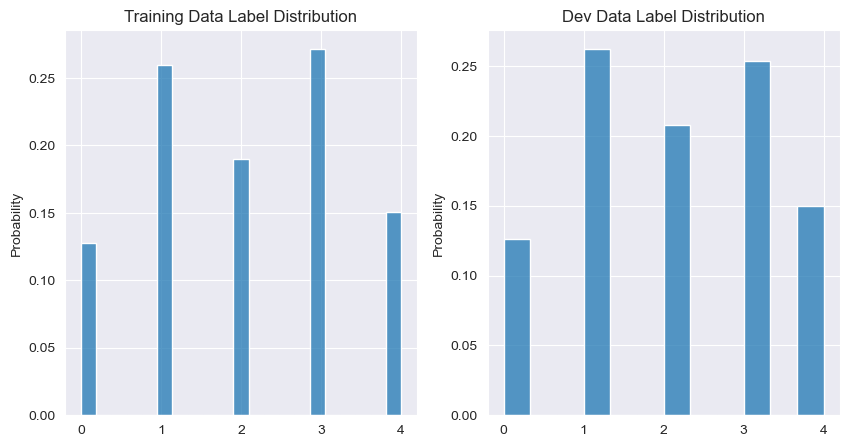

In [42]:
# Check label distribution

fig = plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.histplot(y_train_multiclass[:, 0], stat="probability")
plt.title("Training Data Label Distribution")


plt.subplot(1, 2, 2)
sns.histplot(y_dev_multiclass[:, 0], stat="probability")
plt.title("Dev Data Label Distribution")

### Exercise 3.1: Multinomial Logistic Regression (2 Points)

To extend logistic regression to multi-class classification, we can use the softmax function. For a vector $\pmb{z} = [z_1, z_2, \cdots, z_K]$ of K arbitrary real numbers, the softmax function maps them to a probability distribution with each value between 0 and 1 and summing to 1. The softmax function is defined as:

$$\texttt{softmax}(z_i) = \frac{\exp(z_i)}{\sum_{j = 1}^K \exp(z_j)} \quad 1 \leq i \leq K$$

In multinomial logistic regression, we consider a weight vector $\pmb{w}_k$ for each of the K classes, take dot product with input features (also adding a bias term unique for each class) to obtain scores or *logits* for each of the classes. We then apply the softmax function to get the probability distribution over the classes. Formally, this is given by:

$$\hat{y}_k = P(y_k = 1 \mid \pmb{x}) = \frac{\exp(\pmb{w}_k^T \pmb{x} + b_k)}{\sum_{j=1}^{K}\exp(\pmb{w}_j^T \pmb{x} + b_j)} $$

where $P(y_k = 1 \mid \pmb{x})$ is the probability of the input $\pmb{x}$ belonging to class $k$. $\pmb{w}_k$ is the weight vector for class $k$, and $b_k$ is the bias term for class $k$.

**Note**: In practice, we often use a trick to make the computation of softmax more numerically stable. We subtract the maximum value from the logits before applying softmax. This does not change the output of softmax but can prevent numerical overflow. The softmax function with this trick is given by:

$$\texttt{softmax}(z_i) = \frac{\exp(z_i - \max(\pmb{z}))}{\sum_{j = 1}^K \exp(z_j - \max(\pmb{z}))} \quad 1 \leq i \leq K$$

Implement the `MultinomialLogisticRegression` class below, which initializes the weights and biases for each class and provides a method to get the output from the model.

In [44]:
class MultinomialLogisticRegression:

    def __init__(
        self,
        d: int,
        K: int
    ):

        """
        Initialize the weights and bias to zeros for the multinomial logistic regression model.

        Inputs:
        - d: An integer representing the number of features
        - K: An integer representing the number of classes
        """

        self.weights = torch.zeros(d, K)
        self.bias = torch.zeros(K)

        # YOUR CODE HERE

    def softmax(self, z: torch.FloatTensor) -> torch.FloatTensor:
        """
        Applies the softmax function to the input tensor z

        Inputs:
        - z : A torch.FloatTensor of shape (N, K) where N is the number of samples and K is the number of classes

        Returns:
        - A torch.FloatTensor of shape (N, K) where N is the number of samples and K is the number of classes containing the softmax output

        Note: Apply the trick to avoid overflow while computing the softmax.
        """

        # YOUR CODE HERE
        z_max = torch.max(z, dim=1, keepdim=True).values
        return torch.exp(z - z_max) / torch.sum(torch.exp(z - z_max), dim=1, keepdim=True)


    def forward(self, x: torch.FloatTensor) -> torch.FloatTensor:
        """

        Compute the forward pass of the multinomial logistic regression model.

        Inputs:
        - x : A torch.FloatTensor of shape (N, d) where N is the number of samples and d number of features

        Returns:
        - A torch.FloatTensor of shape (N, K) where N is the number of samples and K is the number of classes

        """

        # YOUR CODE HERE
        return self.softmax(x @ self.weights + self.bias)

    def __call__(self, x: torch.FloatTensor) -> torch.FloatTensor:

        return self.forward(x)



In [45]:
# Sample Test Cases

print("Testing Softmax Function")
torch.manual_seed(42)
z = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)
model = MultinomialLogisticRegression(d=3, K=3)
output = model.softmax(z)
expected_output = torch.tensor(
    [
        [0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]
    ]
)
print(f"Input: {z}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(output, expected_output, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("*"*10+"\n")

z = torch.tensor([[100, 200, 300, 400], [400, 500, 600, 700]], dtype=torch.float)
output = model.softmax(z)
expected_output = torch.tensor(
    [
        [0.0000, 0.0000, 0.0000, 1.0000],
        [0.0000, 0.0000, 0.0000, 1.0000]
    ]
)

print(f"Input: {z}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(output, expected_output, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("*" * 10 + "\n")

print("Testing forward function")
torch.manual_seed(42)
model = MultinomialLogisticRegression(d=3, K=3)
x = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)
y = model(x)
expected_output = torch.tensor(
    [
        [0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333]
    ]
)
print(f"Input: {x}")
print(f"Output: {y}")
print(f"Expected Output: {expected_output}")
if torch.allclose(y, expected_output, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("*" * 10 + "\n")

model = MultinomialLogisticRegression(d=4, K=3)
torch.manual_seed(42)
model.weights = torch.randn(4, 3)
model.bias = torch.randn(3)
x = torch.tensor([[1, 2, 3, 4], [4, 5, 6, 7]], dtype=torch.float)
y = model(x)
expected_output = torch.tensor(
    [[9.9777e-01, 1.8786e-06, 2.2236e-03], [9.9999e-01, 7.6075e-12, 1.2665e-05]]
)
print(f"Input: {x}")
print(f"Model Weights: {model.weights}")
print(f"Model Bias: {model.bias}")
print(f"Output: {y}")
print(f"Expected Output: {expected_output}")
if torch.allclose(y, expected_output, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

Testing Softmax Function
Input: tensor([[1., 2., 3.],
        [4., 5., 6.]])
Output: tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])
Expected Output: tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])
Test Case Passed :)
**********

Input: tensor([[100., 200., 300., 400.],
        [400., 500., 600., 700.]])
Output: tensor([[0.0000e+00, 0.0000e+00, 3.7835e-44, 1.0000e+00],
        [0.0000e+00, 0.0000e+00, 3.7835e-44, 1.0000e+00]])
Expected Output: tensor([[0., 0., 0., 1.],
        [0., 0., 0., 1.]])
Test Case Passed :)
**********

Testing forward function
Input: tensor([[1., 2., 3.],
        [4., 5., 6.]])
Output: tensor([[0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333]])
Expected Output: tensor([[0.3333, 0.3333, 0.3333],
        [0.3333, 0.3333, 0.3333]])
Test Case Passed :)
Input: tensor([[1., 2., 3., 4.],
        [4., 5., 6., 7.]])
Model Weights: tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863],
        [ 2.2082

### Exercise 3.2 Cross Entropy Loss for Multinomial Logistic Regression (1 Point)

The loss function for multinomial logistic regression is the cross entropy loss. For a given input $\pmb{x}$ and ground truth label $\pmb{y}$, the cross entropy loss is given by:

$$L_{\text{CE}}(\pmb{\hat{y}}, \pmb{y}) = -\sum_{k=1}^{K} y_k \log \hat{y}_k$$

$$L_{\text{CE}}(\pmb{w}, \pmb{b} \mid \pmb{x}, \pmb{y}) = -\sum_{k=1}^{K} y_k \log \frac{\exp(\pmb{w}_k^T\pmb{x} + b_k)}{\sum_{j=1}^K \exp(\pmb{w}_j^T\pmb{x} + b_j)}$$

where $\pmb{\hat{y}}$ is the predicted probability distribution over the classes and $\pmb{y}$ is the one-hot encoded ground truth label, such that $y_k = 1$ if the input belongs to class $k$ and 0 otherwise. We can compute the loss over the entire dataset $D$ by averaging the loss over all examples:

$$L_{\text{CE}}(\pmb{w}, \pmb{b} \mid D) = \frac{1}{m} \sum_{i=1}^{m} L_{\text{CE}}(\pmb{\hat{y}_i}, \pmb{y_i})$$

Implement the `cross_entropy_loss` function below, that takes in the predicted and ground truth labels and computes the average cross entropy loss. Use vectorized operations to compute the loss.

In [47]:
def ce_loss(
    y_pred : torch.FloatTensor,
    y_true : torch.FloatTensor
) -> float:
    """
    Compute the cross entropy loss between y_pred and y_true.

    Inputs:
    - y_pred : A torch.FloatTensor of shape (m, K) where m is the number of samples and K is the number of classes
    - y_true : A torch.FloatTensor of shape (m, 1) where m is the number of samples

    Note that y_true is a tensor of class indices and not one-hot encoded.

    Returns:
    - A float representing the cross entropy loss
    """

    # YOUR CODE HERE
    y_true_one_hot = torch.zeros_like(y_pred)
    y_true_one_hot.scatter_(1, y_true, 1)
    return torch.mean(-torch.sum(y_true_one_hot * torch.log(y_pred), dim=1)).item()


In [48]:
# Sample Test Cases

print("Running Sample Test Case 1")
y_pred = torch.tensor([[0.2, 0.3, 0.5], [0.7, 0.2, 0.1]])
y_true = torch.tensor([0, 1]).unsqueeze(1)
output = ce_loss(y_pred, y_true)
expected_output = 1.6094
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

print("Running Sample Test Case 2")
y_pred = torch.tensor([[0.2, 0.3, 0.5], [0.7, 0.2, 0.1]])
y_true = torch.tensor([2, 1]).unsqueeze(1)
output = ce_loss(y_pred, y_true)
expected_output = 1.1513
print(f"y_pred: {y_pred}")
print(f"y_true: {y_true}")
print(f"Output: {output}")
print(f"Expected Output: {expected_output}")
if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

Running Sample Test Case 1
y_pred: tensor([[0.2000, 0.3000, 0.5000],
        [0.7000, 0.2000, 0.1000]])
y_true: tensor([[0],
        [1]])
Output: 1.6094379425048828
Expected Output: 1.6094
Test Case Passed :)
**********************************

Running Sample Test Case 2
y_pred: tensor([[0.2000, 0.3000, 0.5000],
        [0.7000, 0.2000, 0.1000]])
y_true: tensor([[2],
        [1]])
Output: 1.1512925624847412
Expected Output: 1.1513
Test Case Passed :)
**********************************



C:\Users\Rohan Mukherjee\AppData\Local\Temp\ipykernel_262856\3519419611.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):
C:\Users\Rohan Mukherjee\AppData\Local\Temp\ipykernel_262856\3519419611.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.allclose(torch.tensor(output), torch.tensor(expected_output), atol=1e-4):


### Exercise 3.3: Gradient Descent for Multinomial Logistic Regression (3 Points)

The gradient of the cross entropy loss w.r.t the weights and biases can be computed as follows:

$$\nabla_{\pmb{w}_k} L_{\text{CE}}(\pmb{\hat{y}}, \pmb{y}) = (\pmb{\hat{y}} - \pmb{y})^T \pmb{x}$$

$$\nabla_{b_k} L_{\text{CE}}(\pmb{\hat{y}}, \pmb{y}) = \pmb{\hat{y}} - \pmb{y}$$

The gradient descent update rule for the weights and biases is given by:

$$\pmb{w}_k^{t+1} = \pmb{w}_k^{t} - \frac{\eta}{m} \sum_{i=1}^{m} (\pmb{\hat{y}_i} - \pmb{y_i})^T \pmb{x_i}$$

$$b_k^{t+1} = b_k^{t} - \frac{\eta}{m} \sum_{i=1}^{m} (\pmb{\hat{y}_i} - \pmb{y_i})$$

Implement the `gradient_descent_update_vectorized` function below, that takes in the weights, biases, inputs, outputs, and learning rate, and returns the updated weights and biases. Use vectorized operations to compute the gradients and update the weights and biases.


In [49]:
def gradient_descent_update_multiclass(
    X: torch.FloatTensor,
    y: torch.FloatTensor,
    y_hat: torch.FloatTensor,
    w: torch.FloatTensor,
    b: torch.FloatTensor,
    learning_rate: float = 0.5,
) :

    """
    Performs gradient descent update on w and b considering the cross entropy loss using matrix operations.

    Inputs:
    - X : A torch.FloatTensor of shape (m, d) where m is the number of samples and d number of features
    - y : A torch.FloatTensor of shape (m, 1) where m is the number of samples
    - y_hat: A torch.FloatTensor of shape (m, K) where K is the number of classes
    - w : A torch.FloatTensor of shape (d, K) where d is the number of features and K is the number of classes
    - b : A torch.FloatTensor of shape (K) where K is the number of classes
    - learning_rate : A float representing the learning rate

    Note: y is a tensor of class indices and not one-hot encoded.

    Outputs:
    - torch.FloatTensor of shape (d, K) representing the updated weights
    - torch.FloatTensor of shape (K) representing the updated bias
    """

    # YOUR CODE HERE
    true_y_one_hot = torch.zeros_like(y_hat)
    true_y_one_hot.scatter_(1, y, 1)
    grad_w = X.T @ (y_hat - true_y_one_hot) / X.shape[0]
    grad_b = torch.mean(y_hat - true_y_one_hot, dim=0)
    return w - learning_rate * grad_w, b - learning_rate * grad_b

In [50]:
# Sample Test Cases

print("Running Sample Test Case")
torch.manual_seed(42)
X = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.float)
y = torch.tensor([0, 1]).unsqueeze(1)
model = MultinomialLogisticRegression(d=3, K=3)
model.weights = torch.tensor([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6], [0.7, 0.8, 0.9]], dtype=torch.float)
model.bias = torch.tensor([0.1, 0.2, 0.3], dtype=torch.float)
y_hat = model(X)
updated_weights, updated_bias = gradient_descent_update_multiclass(X, y, y_hat, model.weights, model.bias, 0.1)

expected_updated_weights = torch.tensor(
    [[0.1364, 0.3533, 0.1104], [0.4777, 0.6809, 0.3415], [0.8189, 1.0085, 0.5725]]
)
expected_updated_bias = torch.tensor([0.1413, 0.2276, 0.2311])
print(f"X: {X}")
print(f"y: {y}")
print(f"y_hat: {y_hat}")
print(f"Model Weights: {model.weights}")
print(f"Model Bias: {model.bias}")
print(f"Predicted Updated weights: {updated_weights}")
print(f"Expected Updated weights: {expected_updated_weights}")
print(f"Predicted Updated bias: {updated_bias}")
print(f"Expected Updated bias: {model.bias}")
if torch.allclose(updated_weights, expected_updated_weights, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")
print("**********************************\n")

Running Sample Test Case
X: tensor([[1., 2., 3.],
        [4., 5., 6.]])
y: tensor([[0],
        [1]])
y_hat: tensor([[0.1415, 0.2849, 0.5737],
        [0.0328, 0.1625, 0.8047]])
Model Weights: tensor([[0.1000, 0.2000, 0.3000],
        [0.4000, 0.5000, 0.6000],
        [0.7000, 0.8000, 0.9000]])
Model Bias: tensor([0.1000, 0.2000, 0.3000])
Predicted Updated weights: tensor([[0.1364, 0.3533, 0.1104],
        [0.4777, 0.6809, 0.3415],
        [0.8189, 1.0085, 0.5725]])
Expected Updated weights: tensor([[0.1364, 0.3533, 0.1104],
        [0.4777, 0.6809, 0.3415],
        [0.8189, 1.0085, 0.5725]])
Predicted Updated bias: tensor([0.1413, 0.2276, 0.2311])
Expected Updated bias: tensor([0.1000, 0.2000, 0.3000])
Test Case Passed :)
**********************************



### Exercise 3.4: Training Multinomial Logistic Regression Model (2 Points)

Implement the `train_multinomial_logistic_regression` function below, that trains a multinomial logistic regression model using mini-batch gradient descent. Follow the same steps as in the binary logistic regression training, but now for the multi-class case.

In [51]:
def train_multinomial_logistic_regression(
    model: MultinomialLogisticRegression,
    X_train: torch.FloatTensor,
    y_train: torch.FloatTensor,
    X_dev: torch.FloatTensor,
    y_dev: torch.FloatTensor,
    num_epochs: int = 100,
    batch_size: int = 128,
    learning_rate: float = 0.5,
    verbose: bool = True,
) -> MultinomialLogisticRegression:

    """
    Trains the multinomial logistic regression model for `num_epochs` epochs using cross entropy loss and gradient descent.

    Inputs:
    - model : An instance of the MultinomialLogisticRegression class
    - X_train : A torch.FloatTensor of shape (m, d) where m is the number of training samples and d number of features
    - y_train : A torch.FloatTensor of shape (m, 1) where m is the number of training samples
    - X_dev : A torch.FloatTensor of shape (n, d) where n is the number of dev samples and d number of features
    - y_dev : A torch.FloatTensor of shape (n, 1) where n is the number of dev samples
    - num_epochs : An integer representing the number of epochs
    - batch_size : An integer representing the batch size
    - learning_rate : A float representing the learning rate
    - verbose : A boolean indicating whether to print the average train loss and dev loss at every epoch

    Returns:
    - MultinomialLogisticRegression : The model with updated weights and bias after training
    """
    # We wll shuffle the training data to avoid any bias from the order of the data
    torch.manual_seed(42)
    indices = torch.randperm(X_train.shape[0])
    X_train = X_train[indices]
    y_train = y_train[indices]

    # YOUR CODE HERE
    for _ in range(num_epochs):

      train_loss = []
      dev_loss = []

      for i in range(0, X_train.shape[0], batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        y_hat = model(X_batch)

        train_loss.append(ce_loss(y_hat, y_batch))
        model.weights, model.bias = gradient_descent_update_multiclass(X_batch, y_batch, y_hat, model.weights, model.bias, learning_rate)

      if verbose:
        print(f"avg. train loss: {np.mean(train_loss).item()}")
        print(f"dev loss: {ce_loss(model(X_dev), y_dev)}")

    return model

Let's start by training our model on linguistic features

In [52]:
batch_size = 1024
lr = 0.1
num_epochs = 1000

multiclass_logistic_regression_lf = MultinomialLogisticRegression(d=6, K=5)
multiclass_logistic_regression_lf = train_multinomial_logistic_regression(
    multiclass_logistic_regression_lf,
    X_train=train_features,
    y_train=y_train_multiclass,
    X_dev=dev_features,
    y_dev=y_dev_multiclass,
    num_epochs=num_epochs,
    batch_size=batch_size,
    learning_rate=lr,
    verbose=True
)

avg. train loss: 1.5705193281173706
dev loss: 1.5499545335769653
avg. train loss: 1.5369677543640137
dev loss: 1.5312641859054565
avg. train loss: 1.5204700231552124
dev loss: 1.5186669826507568
avg. train loss: 1.5088831186294556
dev loss: 1.5097955465316772
avg. train loss: 1.500477910041809
dev loss: 1.5034308433532715
avg. train loss: 1.494267225265503
dev loss: 1.4988040924072266
avg. train loss: 1.4896082878112793
dev loss: 1.4954065084457397
avg. train loss: 1.4860670566558838
dev loss: 1.4928921461105347
avg. train loss: 1.483343243598938
dev loss: 1.4910207986831665
avg. train loss: 1.4812257289886475
dev loss: 1.4896225929260254
avg. train loss: 1.4795631170272827
dev loss: 1.4885759353637695
avg. train loss: 1.4782456159591675
dev loss: 1.4877926111221313
avg. train loss: 1.4771925210952759
dev loss: 1.4872075319290161
avg. train loss: 1.476344108581543
dev loss: 1.4867727756500244
avg. train loss: 1.4756548404693604
dev loss: 1.4864522218704224
avg. train loss: 1.4750907421

You should see a train loss of 1.479 and a dev loss of roughly 1.483 at the end of the training. The numbers can differ slightly based on how you averaged the losses (order of magnitude 0.01) but not significantly.

Now let's train using BOW features

In [53]:

# Train using BOW features

batch_size = 1024
lr = 0.1
num_epochs = 1000

multiclass_logistic_regression_bow = MultinomialLogisticRegression(d=len(train_bow_features[0]), K=5)
multiclass_logistic_regression_bow = train_multinomial_logistic_regression(
    multiclass_logistic_regression_bow,
    X_train=train_bow_features,
    y_train=y_train_multiclass,
    X_dev=dev_bow_features,
    y_dev=y_dev_multiclass,
    num_epochs=num_epochs,
    batch_size=batch_size,
    learning_rate=lr,
    verbose=True
)

avg. train loss: 1.5859092473983765
dev loss: 1.5803241729736328
avg. train loss: 1.5727545022964478
dev loss: 1.5769065618515015
avg. train loss: 1.5687203407287598
dev loss: 1.5740801095962524
avg. train loss: 1.565467119216919
dev loss: 1.5716629028320312
avg. train loss: 1.5626105070114136
dev loss: 1.569560170173645
avg. train loss: 1.560031533241272
dev loss: 1.567696213722229
avg. train loss: 1.5576597452163696
dev loss: 1.566016674041748
avg. train loss: 1.5554473400115967
dev loss: 1.5644811391830444
avg. train loss: 1.5533595085144043
dev loss: 1.5630607604980469
avg. train loss: 1.5513710975646973
dev loss: 1.561733603477478
avg. train loss: 1.5494630336761475
dev loss: 1.5604828596115112
avg. train loss: 1.5476218461990356
dev loss: 1.559295892715454
avg. train loss: 1.5458356142044067
dev loss: 1.558163046836853
avg. train loss: 1.5440962314605713
dev loss: 1.55707585811615
avg. train loss: 1.542397379875183
dev loss: 1.5560286045074463
avg. train loss: 1.5407335758209229


You should see a train loss of 0.813 and a dev loss of roughly 1.433 at the end of the training. Again, the loss values are lower for both train and dev splits compared to the linguistic features model. However, the gap between train and dev losses is much bigger for the BOW model, indicating overfitting.

### Exercise 3.5: Evaluating Multinomial Logistic Regression (3 Points)

We will again evaluate our model using the same metrics as before. Note that for metrics precision and recall, for the multi-class case, we compute them for each class and then average them to get the final precision and recall. We consider each class one by one as positive (and others negative) and compute the precision and recall values. This is called macro-averaging. Accuracy can be computed in the same way as before and F1-score can be computed as the harmonic mean of precision and recall.

This time you will compute another metric called the confusion matrix. The confusion matrix for multi-class classification is a K x K matrix where K is the number of classes. The element at row i and column j of the confusion matrix is the number of observations known to be in group i but predicted to be in group j.

Note that for multi-class case, the final prediction of the model $y_{\text{pred}}$ is the class with the highest probability i.e.

$$y_{\text{pred}} = \text{argmax}_k \hat{y}_k$$

Implement the `get_precision_multiclass`, `get_recall_multiclass`, and `get_f1_score_multiclass`, and ``get_confusion_matrix`` functions below.

In [69]:
def get_precision_multiclass(y_pred, y_true, K, epsilon=1e-8):
    """
    Compute the precision of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the predicted labels (after taking the argmax)
    - y_true : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the true labels
    - K : An integer representing the number of classes
    - epsilon : A small value to avoid division by zero

    Returns:
    - A float representing the precision of the model
    """

    # YOUR CODE HERE
    precisions = torch.zeros(K)
    for i in range(K):
        tp = torch.sum((y_pred == i) & (y_true == i))
        fp = torch.sum((y_pred == i) & (y_true != i))
        precisions[i] = tp / (tp + fp + epsilon)
    return torch.mean(precisions).item()

def get_recall_muticlass(
    y_pred, y_true, K, epsilon=1e-8
):
    """
    Compute the recall of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the predicted labels (after taking the argmax)
    - y_true : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the true labels
    - K : An integer representing the number of classes
    - epsilon : A small value to avoid division by zero

    Returns:
    - A float representing the recall of the model
    """
    recalls = torch.zeros(K)
    for i in range(K):
        tp = torch.sum((y_pred == i) & (y_true == i))
        fn = torch.sum((y_pred != i) & (y_true == i))
        recalls[i] = tp/(tp+fn+epsilon)
    
    # YOUR CODE HERE
    return torch.mean(recalls).item()

def get_f1_score_multiclass(y_pred, y_true, K, epsilon=1e-8):
    """
    Compute the F1 score of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the predicted labels (after taking the argmax)
    - y_true : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the true labels
    - K : An integer representing the number of classes
    - epsilon : A small value to avoid division by zero

    Returns:
    - A float representing the F1 score of the model
    """

    # YOUR CODE HERE
    P = get_precision_multiclass(y_pred, y_true, K, epsilon)
    R = get_recall_muticlass(y_pred, y_true, K, epsilon)
    return 2 * P * R / (P + R)

def get_confusion_matrix(y_pred, y_true, K):
    """
    Compute the confusion matrix of the model given the predicted and true labels

    Inputs:
    - y_pred : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the predicted labels (after taking the argmax)
    - y_true : A torch.FloatTensor of shape (N, 1) where N is the number of samples representing the true labels
    - K : An integer representing the number of classes

    Returns:
    - A torch.FloatTensor of shape (K, K) representing the confusion matrix of the model
    """

    # YOUR CODE HERE
    confusion_matrix = torch.zeros((K,K))
    for i in range(len(y_pred)):
        confusion_matrix[int(y_true[i])][int(y_pred[i])] += 1
    return confusion_matrix

In [70]:
# Sample Test Cases

print("Running Sample Test Case")
y_true = torch.tensor([0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4]).unsqueeze(1)
y_pred = torch.tensor([0, 0, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 4, 4]).unsqueeze(1)

precision = get_precision_multiclass(y_pred, y_true, 5)
expected_precision = 0.8533332943916321

recall = get_recall_muticlass(y_pred, y_true, 5)
expected_recall = 0.8199999928474426

f1_score = get_f1_score_multiclass(y_pred, y_true, 5)
expected_f1_score = 0.8363346389315565

confusion_matrix = get_confusion_matrix(y_pred, y_true, 5)
expected_confusion_matrix = torch.tensor(
    [
        [2.0, 2.0, 0.0, 0.0, 0.0],
        [0.0, 4.0, 0.0, 0.0, 0.0],
        [0.0, 0.0, 4.0, 0.0, 0.0],
        [0.0, 0.0, 0.0, 3.0, 2.0],
        [0.0, 0.0, 0.0, 0.0, 3.0],
    ]
)


print(f"Predicted Labels: {y_pred}")
print(f"True Labels: {y_true}")

print("Sample Test Case 1: Precision")
print(f"Predicted Precision: {precision}")
print(f"Expected Precision: {expected_precision}")
if torch.allclose(torch.tensor(precision), torch.tensor(expected_precision), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

print("Sample Test Case 2: Recall")
print(f"Predicted Recall: {recall}")
print(f"Expected Recall: {expected_recall}")
if torch.allclose(torch.tensor(recall), torch.tensor(expected_recall), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

print("Sample Test Case 3: F1 Score")
print(f"Predicted F1 Score: {f1_score}")
print(f"Expected F1 Score: {expected_f1_score}")
if torch.allclose(torch.tensor(f1_score), torch.tensor(expected_f1_score), atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

print("Sample Test Case 4: Confusion Matrix")
print(f"Predicted Confusion Matrix: {confusion_matrix}")
print(f"Expected Confusion Matrix: {expected_confusion_matrix}")
if torch.allclose(confusion_matrix, expected_confusion_matrix, atol=1e-4):
    print("Test Case Passed :)")
else:
    print("Test Case Failed :(")

print("**********************************\n")

Running Sample Test Case
Predicted Labels: tensor([[0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [1],
        [1],
        [2],
        [2],
        [2],
        [2],
        [3],
        [3],
        [3],
        [4],
        [4],
        [4],
        [4],
        [4]])
True Labels: tensor([[0],
        [0],
        [0],
        [0],
        [1],
        [1],
        [1],
        [1],
        [2],
        [2],
        [2],
        [2],
        [3],
        [3],
        [3],
        [3],
        [3],
        [4],
        [4],
        [4]])
Sample Test Case 1: Precision
Predicted Precision: 0.8533332943916321
Expected Precision: 0.8533332943916321
Test Case Passed :)
**********************************

Sample Test Case 2: Recall
Predicted Recall: 0.8199999928474426
Expected Recall: 0.8199999928474426
Test Case Passed :)
**********************************

Sample Test Case 3: F1 Score
Predicted F1 Score: 0.8363346457481384
Expected F1 Score: 0.836334638931

C:\Users\Rohan Mukherjee\AppData\Local\Temp\ipykernel_262856\1041965939.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.allclose(torch.tensor(precision), torch.tensor(expected_precision), atol=1e-4):
C:\Users\Rohan Mukherjee\AppData\Local\Temp\ipykernel_262856\1041965939.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  if torch.allclose(torch.tensor(recall), torch.tensor(expected_recall), atol=1e-4):
C:\Users\Rohan Mukherjee\AppData\Local\Temp\ipykernel_262856\1041965939.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).

Similar to the binary case, you will implement `evaluate_multinomial_logistic_regression` that evaluates a multinomial logistic regression model on the 5 metrics (accuracy, precision, recall, f1-score, and confusion matrix).

In [ ]:
def evaluate_multiclass_logistic_regression(
    model: MultinomialLogisticRegression,
    X: torch.FloatTensor,
    y: torch.FloatTensor,
    eval_batch_size: int = 128,
):

    """
    Evaluate the multinomial logistic regression model on the given data using the given threshold

    Inputs:
    - model : An instance of the MultinomialLogisticRegression class
    - X : A torch.FloatTensor of shape (N, d) where N is the number of samples and d number of features representing the input data
    - y : A torch.FloatTensor of shape (N, 1) where N is the number of samples containing the true labels
    - eval_batch_size : An integer representing the batch size to be used for evaluation
    - threshold : A float representing the threshold to be used for binary classification

    Returns:
    - A dictionary containing the precision, recall, f1_score and confusion_matrix of the model
    """

    metrics = {
        "accuracy": None,
        "precision": None,
        "recall": None,
        "f1_score": None,
        "confusion_matrix": None
    }

    # YOUR CODE HERE
    y_pred = model.forward(X)
    y_pred = torch.argmax(y_pred, dim=1)
    
    metrics['accuracy'] = accuracy(y_pred, y)
    metrics['precision'] = get_precision(y_pred, y)
    metrics['recall'] = get_recall(y_pred, y)
    metrics['f1_score'] = get_f1_score(y_pred, y)
    metrics['confusion_matrix'] = get_confusion_matrix(y_pred, y)

    return metrics

In [ ]:
print("Multiclass Logistic Regression with LF Features")
multiclass_lf_eval_metrics = evaluate_multiclass_logistic_regression(
    multiclass_logistic_regression_lf,
    X=dev_features,
    y=y_dev_multiclass,
    eval_batch_size=128
)

print(multiclass_lf_eval_metrics)


In [ ]:
print("Multiclass Logistic Regression with BOW Features")

multiclass_bow_eval_metrics = evaluate_multiclass_logistic_regression(
    multiclass_logistic_regression_bow,
    X=dev_bow_features,
    y=y_dev_multiclass,
    eval_batch_size=128
)

print(multiclass_bow_eval_metrics)


You should observe the following metrics:

Model | Accuracy | Precision | Recall | F1-score
------|----------|-----------|--------|---------
Logistic Regression w Linguistic Features | 0.344 | 0.39 | 0.288 | 0.332 |
Logistic Regression w BOW Features | 0.362 | 0.349 | 0.322 | 0.335 |


You should also see the confusion matrix for the BOW model as:
<!-- [[ 18.,  68.,  22.,  26.,   5.],
        [ 16., 169.,  30.,  65.,   9.],
        [  5.,  92.,  19.,  96.,  17.],
        [  5.,  66.,  27., 145.,  36.],
        [  1.,  24.,  13.,  79.,  48.]] -->

```
[[ 18.,  68.,  22.,  26.,   5.],
[ 16., 169.,  30.,  65.,   9.],
[  5.,  92.,  19.,  96.,  17.],
[  5.,  66.,  27., 145.,  36.],
[  1.,  24.,  13.,  79.,  48.]]
````

Note that the performance of the model is much worse compared to the binary case. This is expected as multi-class classification is a harder problem, with a random classifier having an accuracy of 20% compared to 50% in the binary case. The logistic regression model is also not a very powerful model, specially considering the type of feature representations we used today. In the future homeworks, we will work with more powerful models like neural networks that can capture more complex patterns in the data.


### Hyperparameter Tuning



Similar to the binary case, you will perform hyperparameter tuning for the multinomial logistic regression model. You can either perform a grid search on the hyperparameters or a random search. Report the hyperparameter values that you try, the search method, and the number of trials, along with the best performing hyperparameter setting. Along with your writeup, also provide predictions on the test set (we only provide inputs for the test data), which we will use to evaluate your submission.

Like before, add a column called ``pred_label`` in the test data frame above and fill it with the predictions from your best model. After you add your predictions to the dataframe, save the dataframe as a CSV file (strictly use the name of the file as `test_data_with_multiclass_predictions.csv`) and upload it with your code.


```
# Load test data:
test_df = pd.read_csv(f"{data_dir}/sst_test_release.csv")

#Make Predictions
...

# Save the dataset with predictions
test_df.to_csv("test_data_with_multiclass_predictions.csv")

```


In [ ]:
learning_rates = np.logspace(-1, -5, num=10, base=np.e)
batch_sizes = np.logspace(3, 12, num=10, base=2)
epochs = np.linspace(2, 1000, num=10)
remove_unk_words = 0
lowercase = 0
remove_punc = 0
remove_stop_words = 0

best_model = None
best_f1 = 0
best_params = None

for i in tqdm.tqdm(range(30)):
  learning_rate = learning_rates[np.random.randint(0, 10)]
  batch_size = int(batch_sizes[np.random.randint(0, 10)])
  num_epochs = int(epochs[np.random.randint(0, 10)])
  remove_unk_words = np.random.randint(0, 2)
  lowercase = np.random.randint(0, 2)
  remove_punc = np.random.randint(0, 2)
  remove_stop_words = np.random.randint(0, 2)

  bow_vectorizer = BOWVectorizerWNormalizer(
      lower_case=lowercase, remove_punctuation=remove_punc, remove_stopwords=remove_stop_words, replace_rare_words_wth_unks=remove_unk_words
  )
  bow_vectorizer.fit(train_df['sentence'].values)
  train_bow_features = bow_vectorizer.transform(train_df['sentence'].values)
  dev_bow_features = bow_vectorizer.transform(dev_df['sentence'].values)
  y_train = torch.tensor(train_df["label"].values).unsqueeze(1)
  y_dev = torch.tensor(dev_df["label"].values).unsqueeze(1)

  model = MultinomialLogisticRegression(len(train_bow_features[0]))
  train_logistic_regression(model, train_bow_features, y_train, dev_bow_features, y_dev, num_epochs=num_epochs, batch_size=batch_size, learning_rate=learning_rate, verbose=False)

  y_pred = (model(dev_bow_features) >= 0.5).float()
  f1 = get_f1_score(y_pred, y_dev)

  if f1 > best_f1:
    best_f1 = f1
    best_model = model
    best_params = (learning_rate, batch_size, num_epochs, remove_unk_words, lowercase, remove_punc, remove_stop_words)
    print('learning rate: ', learning_rate)
    print('batch size: ', batch_size)
    print('num epochs: ', num_epochs)
    print('remove unk words: ', remove_unk_words)
    print('lowercase: ', lowercase)
    print('remove punc: ', remove_punc)
    print('remove stop words: ', remove_stop_words)
    print('f1 score: ', f1)

print(best_params)
print(best_f1)